❌ attackcti not installed - falling back to static mapping

🚀 ENTERPRISE DETECTION ANALYTICS PORTFOLIO
Comprehensive Security Detection Capability Assessment
📁 Loading detection rules dataset...
✅ Successfully loaded 350 detection rules
🔍 Applying data quality enhancements...
🧹 Removed 2 duplicate rules

🔍 DATA QUALITY REPORT
   • Initial rules: 350
   • After cleaning: 348
   • Duplicates removed: 2
   • Rules with 'Unknown' threat: 0
   • Unmapped MITRE techniques: 9
   • Null signatures: 0
   • Empty signatures: 0
📊 Dataset features: ['id', 'threat', 'rule_type', 'signature', 'tool', 'mapped_technique']
🗺️  Initializing MITRE ATT&CK mapping...
❌ attackcti library not installed. Please run: pip install attackcti
⚠️  Using enhanced static mapping (install attackcti for live MITRE data)
📊 Applying MITRE ATT&CK tactical mapping to dataset...
✅ MITRE mapping applied. Tactic distribution:
mitre_tactic
Execution               57
Other                   43
Command and Control     40
Lateral

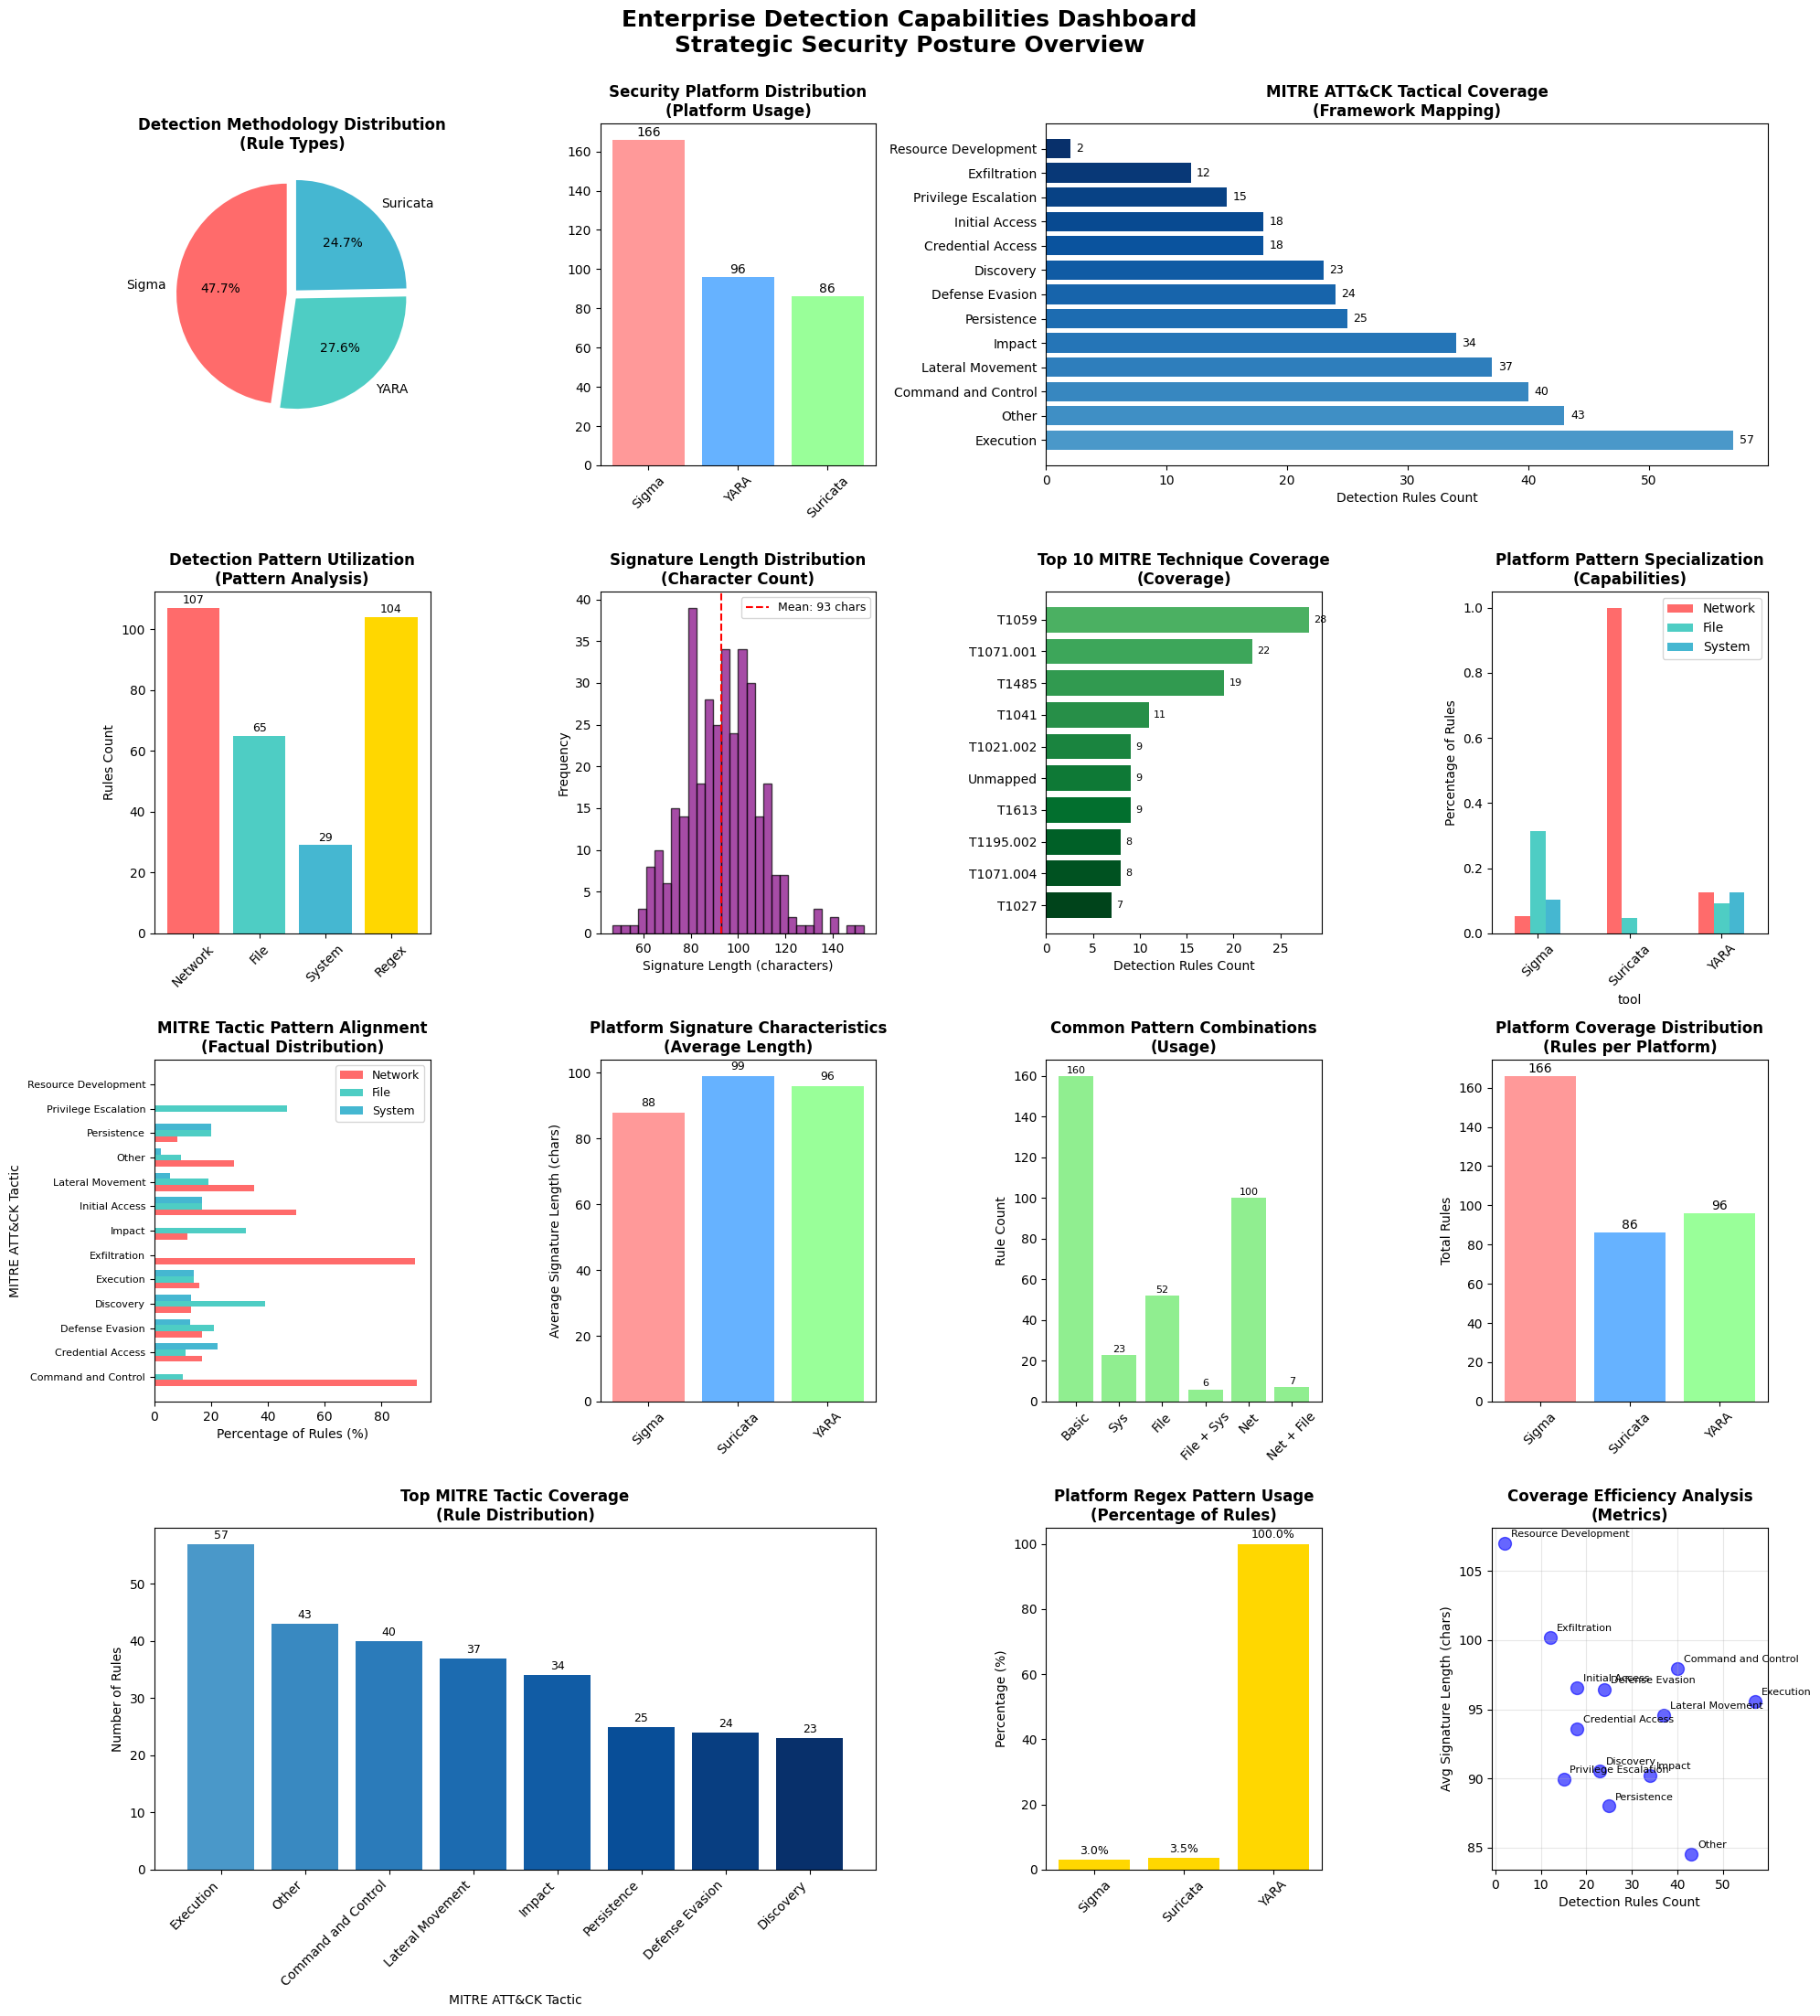

✅ Executive Dashboard - 14 Strategic Views

📊 EXECUTIVE DASHBOARD KEY METRICS:
--------------------------------------------------
📈 DETECTION SCALE & COVERAGE:
  • Detection Portfolio: 348 rules across 3 platforms
  • MITRE ATT&CK Coverage: 12/14 tactics (85.7%)
  • MITRE Technique Coverage: 111 techniques

🔍 MITRE ATT&CK TACTICAL COVERAGE BREAKDOWN:
   1. Reconnaissance            ✗ (0 rules)
   2. Resource Development      ✓ (2 rules)
   3. Initial Access            ✓ (18 rules)
   4. Execution                 ✓ (57 rules)
   5. Persistence               ✓ (25 rules)
   6. Privilege Escalation      ✓ (15 rules)
   7. Defense Evasion           ✓ (24 rules)
   8. Credential Access         ✓ (18 rules)
   9. Discovery                 ✓ (23 rules)
  10. Lateral Movement          ✓ (37 rules)
  11. Collection                ✗ (0 rules)
  12. Command and Control       ✓ (40 rules)
  13. Exfiltration              ✓ (12 rules)
  14. Impact                    ✓ (34 rules)

📊 MITRE ATT&CK: 85.

In [74]:
# Copyright (c) 2025 Vitor Anjos. All rights reserved.

# =============================================================================
# ENTERPRISE DETECTION ANALYTICS PORTFOLIO
# =============================================================================
"""
Comprehensive security detection capability assessment
Strategic analysis for detection engineering and security operations
"""

# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import re

# MITRE ATT&CK official library
try:
    from attackcti import attack_client
    MITRE_CTI_AVAILABLE = True
    print("✅ attackcti library available - using official MITRE STIX data\n")
except ImportError:
    MITRE_CTI_AVAILABLE = False
    print("❌ attackcti not installed - falling back to static mapping\n")

# =============================================================================
# PROFESSIONAL VISUALIZATION CONFIGURATION
# =============================================================================

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("🚀 ENTERPRISE DETECTION ANALYTICS PORTFOLIO")
print("=" * 70)
print("Comprehensive Security Detection Capability Assessment")
print("=" * 70)

# =============================================================================
# DETECTION PORTFOLIO QUALITY ASSESSMENT
# =============================================================================

def analyze_detection_quality(df):
    """
    Comprehensive detection portfolio quality assessment
    Provides measurable metrics for detection capability evaluation

    Returns:
        dict: Portfolio quality metrics for strategic decision-making
    """
    standard_tactics = [
        'Reconnaissance', 'Resource Development', 'Initial Access', 'Execution',
        'Persistence', 'Privilege Escalation', 'Defense Evasion', 'Credential Access',
        'Discovery', 'Lateral Movement', 'Collection', 'Command and Control',
        'Exfiltration', 'Impact'
    ]

    covered_tactics = len([t for t in standard_tactics
                          if t in df['mitre_tactic'].values and len(df[df['mitre_tactic'] == t]) > 0])

    metrics = {
        'total_rules': len(df),
        'system_coverage_pct': df['has_system_indicators'].mean() * 100,
        'network_coverage_pct': df['has_network_indicators'].mean() * 100,
        'file_coverage_pct': df['has_file_indicators'].mean() * 100,
        'mitre_technique_coverage': df['mapped_technique'].nunique(),
        'mitre_tactic_coverage': f"{covered_tactics}/{len(standard_tactics)}",
        'mitre_coverage_percentage': (covered_tactics / len(standard_tactics)) * 100,
        'unclassified_rules': len(df[df['mitre_tactic'] == 'Other']),
        'platform_distribution': df['tool'].value_counts().to_dict(),
        'pattern_utilization': {
            'regex_usage': df['uses_regex'].sum(),
            'network_indicators': df['has_network_indicators'].sum(),
            'file_indicators': df['has_file_indicators'].sum(),
            'system_indicators': df['has_system_indicators'].sum()
        }
    }
    return metrics

# =============================================================================
# DATA QUALITY PIPELINE: ENHANCEMENT & VALIDATION
# =============================================================================

def enhance_data_quality(df):
    """Apply data quality improvements to the dataset"""
    initial_count = len(df)

    print("🔍 Applying data quality enhancements...")

    # 1. Handle nulls and empty strings
    df['threat'] = df['threat'].fillna('Unknown_Threat').replace('', 'Unknown_Threat')
    if 'rule_type' in df.columns:
        df['rule_type'] = df['rule_type'].fillna('Unknown_Type').replace('', 'Unknown_Type')

    # 2. Remove exact signature duplicates
    df_clean = df.drop_duplicates(subset=['signature']).copy()
    duplicates_removed = initial_count - len(df_clean)
    if duplicates_removed > 0:
        print(f"🧹 Removed {duplicates_removed} duplicate rules")

    # 3. Apply MITRE mapping
    df_clean['mapped_technique'] = df_clean['mapped_technique'].replace('T1040', 'Unmapped')

    return df_clean

def data_quality_report(df, initial_count):
    """Generate comprehensive data quality report"""
    duplicates_removed = initial_count - len(df)

    print("\n🔍 DATA QUALITY REPORT")
    print("=" * 50)
    print(f"   • Initial rules: {initial_count:,}")
    print(f"   • After cleaning: {len(df):,}")
    print(f"   • Duplicates removed: {duplicates_removed:,}")
    print(f"   • Rules with 'Unknown' threat: {(df['threat'] == 'Unknown_Threat').sum():,}")
    print(f"   • Unmapped MITRE techniques: {(df['mapped_technique'] == 'Unmapped').sum():,}")
    print(f"   • Null signatures: {df['signature'].isna().sum():,}")
    print(f"   • Empty signatures: {(df['signature'] == '').sum():,}")
    print("=" * 50)

print("📁 Loading detection rules dataset...")

try:
    df_raw = pd.read_json('BLUE_TEAM_DEFENSE_DATASET.jsonl', lines=True)
    initial_count = len(df_raw)
    print(f"✅ Successfully loaded {initial_count:,} detection rules")

    # Enhance data quality
    df = enhance_data_quality(df_raw)
    data_quality_report(df, initial_count)

    print(f"📊 Dataset features: {df.columns.tolist()}")

    # Quick data validation
    required_columns = ['id', 'rule_type', 'signature', 'tool', 'mapped_technique']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        print(f"⚠️  Warning: Missing expected columns: {missing_cols}")

except FileNotFoundError:
    print("\n❌ Dataset file not found!")
    print("\n💡 SETUP REQUIRED:")
    print("1. Download 'BLUE_TEAM_DEFENSE_DATASET.jsonl'")
    print("2. Place it in the same directory as this script")
    print("3. Run the analysis again")
    exit(1)

except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print("💡 Check that the file is valid JSONL format")
    exit(1)

# =============================================================================
# OFFICIAL MITRE ATT&CK TAXONOMY INTEGRATION
# =============================================================================

def initialize_mitre_client():
    """
    Initialize MITRE ATT&CK client with proper STIX object handling
    """
    if not MITRE_CTI_AVAILABLE:
        print("❌ attackcti library not installed. Please run: pip install attackcti")
        return create_enhanced_static_mapping()

    try:
        print("🔗 Initializing MITRE ATT&CK client...")
        lift = attack_client()

        # Cache all techniques to avoid repeated API calls
        print("📥 Fetching official MITRE ATT&CK techniques...")
        all_techniques = lift.get_techniques()

        # Build technique to tactic mapping
        technique_to_tactic = {}

        for technique in all_techniques:
            try:
                # Extract ATT&CK ID from external references
                attack_id = None
                if hasattr(technique, 'external_references'):
                    for ref in technique.external_references:
                        if (hasattr(ref, 'get') and ref.get('source_name') == 'mitre-attack'
                            and ref.get('external_id')):
                            attack_id = ref['external_id']
                            break

                if not attack_id:
                    continue

                # Extract tactics from kill chain phases
                tactics = []
                if hasattr(technique, 'kill_chain_phases'):
                    for phase in technique.kill_chain_phases:
                        # Handle STIX kill chain phase object correctly
                        phase_name = None
                        if hasattr(phase, 'phase_name'):
                            phase_name = phase.phase_name
                        elif isinstance(phase, dict) and 'phase_name' in phase:
                            phase_name = phase['phase_name']

                        if phase_name:
                            # Convert to readable format (e.g., 'command-and-control' -> 'Command And Control')
                            tactic_name = phase_name.replace('-', ' ').title()
                            tactics.append(tactic_name)

                if tactics:
                    # Use first tactic as primary
                    technique_to_tactic[attack_id] = tactics[0]
                    # Debug: Uncomment to see mapping
                    # print(f"  {attack_id} -> {tactics[0]}")

            except Exception as e:
                # Skip individual technique errors but continue processing
                continue

        print(f"✅ MITRE mapping loaded: {len(technique_to_tactic)} techniques")

        # Show sample of mapped techniques
        print("📋 Sample mappings:")
        sample_techniques = list(technique_to_tactic.items())[:5]
        for tech, tactic in sample_techniques:
            print(f"   {tech} → {tactic}")

        return technique_to_tactic

    except Exception as e:
        print(f"❌ Error initializing MITRE client: {e}")
        print("💡 Falling back to static mapping...")
        return create_enhanced_static_mapping()

def create_enhanced_static_mapping():
    """
    Static mapping as fallback when MITRE client fails
    """
    print("⚠️  Using enhanced static mapping (install attackcti for live MITRE data)")

    # Enhanced mapping with proper tactic names that match your chart expectations
    enhanced_mapping = {
        # Reconnaissance
        'T1595': 'Reconnaissance', 'T1592': 'Reconnaissance', 'T1589': 'Reconnaissance',
        'T1590': 'Reconnaissance', 'T1591': 'Reconnaissance', 'T1598': 'Reconnaissance',
        'T1597': 'Reconnaissance', 'T1596': 'Reconnaissance', 'T1593': 'Reconnaissance',
        'T1594': 'Reconnaissance',

        # Resource Development
        'T1583': 'Resource Development', 'T1586': 'Resource Development',
        'T1584': 'Resource Development', 'T1587': ' Resource Development',
        'T1585': 'Resource Development', 'T1588': 'Resource Development',

        # Initial Access
        'T1566': 'Initial Access', 'T1190': 'Initial Access', 'T1133': 'Initial Access',
        'T1200': 'Initial Access', 'T1091': 'Initial Access', 'T1189': 'Initial Access',
        'T1195': 'Initial Access', 'T1199': 'Initial Access', 'T1078': 'Initial Access',

        # Execution
        'T1059': 'Execution', 'T1203': 'Execution', 'T1204': 'Execution', 'T1053': 'Execution',
        'T1064': 'Execution', 'T1569': 'Execution', 'T1047': 'Execution', 'T1056': 'Execution',
        'T1106': 'Execution', 'T1129': 'Execution', 'T1072': 'Execution', 'T1609': 'Execution',
        'T1059.001': 'Execution', 'T1059.003': 'Execution', 'T1059.005': 'Execution',
        'T1059.006': 'Execution', 'T1059.007': 'Execution',

        # Persistence
        'T1547': 'Persistence', 'T1136': 'Persistence', 'T1543': 'Persistence',
        'T1546': 'Persistence', 'T1574': 'Persistence', 'T1525': 'Persistence',
        'T1556': 'Persistence', 'T1133': 'Persistence', 'T1505': 'Persistence',
        'T1542': 'Persistence', 'T1037': 'Persistence',

        # Privilege Escalation
        'T1548': 'Privilege Escalation', 'T1134': 'Privilege Escalation',
        'T1068': 'Privilege Escalation', 'T1055': 'Privilege Escalation',
        'T1611': 'Privilege Escalation',

        # Defense Evasion
        'T1562': 'Defense Evasion', 'T1070': 'Defense Evasion', 'T1027': 'Defense Evasion',
        'T1036': 'Defense Evasion', 'T1553': 'Defense Evasion', 'T1222': 'Defense Evasion',
        'T1564': 'Defense Evasion', 'T1578': 'Defense Evasion', 'T1112': 'Defense Evasion',
        'T1601': 'Defense Evasion', 'T1218': 'Defense Evasion', 'T1550': 'Defense Evasion',

        # Credential Access
        'T1003': 'Credential Access', 'T1110': 'Credential Access', 'T1555': 'Credential Access',
        'T1558': 'Credential Access', 'T1528': 'Credential Access', 'T1552': 'Credential Access',
        'T1621': 'Credential Access', 'T1539': 'Credential Access', 'T1111': 'Credential Access',
        'T1003.001': 'Credential Access', 'T1003.002': 'Credential Access',

        # Discovery
        'T1082': 'Discovery', 'T1016': 'Discovery', 'T1033': 'Discovery', 'T1049': 'Discovery',
        'T1069': 'Discovery', 'T1057': 'Discovery', 'T1018': 'Discovery', 'T1083': 'Discovery',
        'T1615': 'Discovery', 'T1518': 'Discovery', 'T1087': 'Discovery', 'T1040': 'Discovery',
        'T1201': 'Discovery', 'T1120': 'Discovery', 'T1135': 'Discovery', 'T1007': 'Discovery',
        'T1124': 'Discovery', 'T1063': 'Discovery',

        # Lateral Movement
        'T1021': 'Lateral Movement', 'T1570': 'Lateral Movement', 'T1550': 'Lateral Movement',
        'T1563': 'Lateral Movement', 'T1020': 'Lateral Movement', 'T1091': 'Lateral Movement',
        'T1080': 'Lateral Movement',

        # Collection
        'T1113': 'Collection', 'T1123': 'Collection', 'T1115': 'Collection', 'T1114': 'Collection',
        'T1213': 'Collection', 'T1185': 'Collection', 'T1530': 'Collection', 'T1602': 'Collection',
        'T1560': 'Collection', 'T1119': 'Collection', 'T1125': 'Collection', 'T1039': 'Collection',
        'T1025': 'Collection',

        # Command and Control
        'T1071': 'Command and Control', 'T1090': 'Command and Control', 'T1573': 'Command and Control',
        'T1571': 'Command and Control', 'T1572': 'Command and Control', 'T1008': 'Command and Control',
        'T1105': 'Command and Control', 'T1104': 'Command and Control', 'T1095': 'Command and Control',
        'T1568': 'Command and Control', 'T1071.001': 'Command and Control',

        # Exfiltration
        'T1041': 'Exfiltration', 'T1020': 'Exfiltration', 'T1030': 'Exfiltration',
        'T1048': 'Exfiltration', 'T1011': 'Exfiltration', 'T1052': 'Exfiltration',
        'T1567': 'Exfiltration', 'T1029': 'Exfiltration', 'T1537': 'Exfiltration',

        # Impact
        'T1485': 'Impact', 'T1486': 'Impact', 'T1490': 'Impact', 'T1565': 'Impact',
        'T1491': 'Impact', 'T1495': 'Impact', 'T1496': 'Impact', 'T1498': 'Impact',
        'T1499': 'Impact', 'T1529': 'Impact', 'T1531': 'Impact'
    }

    return enhanced_mapping

def map_mitre_tactic_official(technique_id, technique_mapping):
    """
    Map MITRE ATT&CK techniques to tactical categories using official taxonomy.
    """
    if pd.isna(technique_id) or technique_id == 'Other' or technique_id == 'Unmapped':
        return 'Other'

    # Handle sub-techniques by using base technique ID
    base_technique = technique_id.split('.')[0]

    # First try exact match (for sub-techniques)
    if technique_id in technique_mapping:
        return technique_mapping[technique_id]

    # Then try base technique match
    if base_technique in technique_mapping:
        return technique_mapping[base_technique]

    return 'Other'

# Initialize MITRE mapping
print("🗺️  Initializing MITRE ATT&CK mapping...")
mitre_mapping = initialize_mitre_client()

# Apply MITRE ATT&CK tactical mapping
print("📊 Applying MITRE ATT&CK tactical mapping to dataset...")
df['mitre_tactic'] = df['mapped_technique'].apply(
    lambda x: map_mitre_tactic_official(x, mitre_mapping)
)

# Show mapping results
print(f"✅ MITRE mapping applied. Tactic distribution:")
print(df['mitre_tactic'].value_counts())

# =============================================================================
# CLASSIFICATION ACCURACY ASSESSMENT
# =============================================================================

# Comprehensive analysis of mapping quality and unclassified rules
# Distinguishes between unmapped techniques and rules in 'Other' tactic category
print("\n🔍 CLASSIFICATION BREAKDOWN:")
print("=" * 50)
print(f"Unmapped techniques: {len(df[df['mapped_technique'] == 'Unmapped'])} rules")
print(f"'Other' MITRE tactic: {len(df[df['mitre_tactic'] == 'Other'])} rules")

# Check if there's overlap between unmapped techniques and 'Other' category
unmapped_techniques = df[df['mapped_technique'] == 'Unmapped']
unmapped_in_other = unmapped_techniques[unmapped_techniques['mitre_tactic'] == 'Other']
print(f"Unmapped techniques in 'Other' tactic: {len(unmapped_in_other)} rules")

# Total truly unclassified (either unmapped or in 'Other' category)
total_unclassified = len(df[(df['mapped_technique'] == 'Unmapped') | (df['mitre_tactic'] == 'Other')])
print(f"Total unclassified rules: {total_unclassified} rules ({(total_unclassified/len(df))*100:.1f}%)")
print("=" * 50)

# =============================================================================
# DETECTION RULE FEATURE ENGINEERING
# =============================================================================

# Create a copy to avoid SettingWithCopyWarning
df = df.copy()

# Calculate signature characteristics
df['signature_length'] = df['signature'].str.len()

# Detection pattern indicators
df['has_network_indicators'] = df['signature'].str.contains('alert|tcp|udp|http|dns|port|ip\\.', case=False, na=False)
df['has_file_indicators'] = df['signature'].str.contains('file|executable|\\.exe|\\.dll|\\.ps1|\\.bat|\\.scr', case=False, na=False)
df['has_system_indicators'] = df['signature'].str.contains('registry|process|service|eventlog|wmi', case=False, na=False)
df['uses_regex'] = df['signature'].str.contains('\\*|\\.\\*|\\+|\\?|\\[.*\\]|\\^|\\$', na=False)

# =============================================================================
# DYNAMIC METRICS CALCULATION
# =============================================================================

def get_actual_metrics(df):
    """Calculate metrics from the dataset"""
    actual_metrics = {
        'total_rules': len(df),
        'sigma_rules': len(df[df['tool'] == 'Sigma']) if 'Sigma' in df['tool'].values else 0,
        'suricata_rules': len(df[df['tool'] == 'Suricata']) if 'Suricata' in df['tool'].values else 0,
        'yara_rules': len(df[df['tool'] == 'YARA']) if 'YARA' in df['tool'].values else 0,
        'other_rules': len(df[df['mitre_tactic'] == 'Other']),
        'system_rules': df['has_system_indicators'].sum(),
        'network_rules': df['has_network_indicators'].sum(),
        'file_rules': df['has_file_indicators'].sum(),
        'regex_rules': df['uses_regex'].sum(),
        'avg_signature_length': df['signature_length'].mean()
    }
    return actual_metrics

# Calculate metrics
actual = get_actual_metrics(df)

print(f"\n🎯 CRITICAL DETECTION PORTFOLIO INSIGHTS:")
print("=" * 60)
print(f"• Platform Distribution: Sigma ({actual['sigma_rules']} rules), Suricata ({actual['suricata_rules']} rules), YARA ({actual['yara_rules']} rules)")
print(f"• Classification Gap: {actual['other_rules']} rules ({actual['other_rules']/actual['total_rules']*100:.1f}%) unclassified in 'Other' MITRE category")
print(f"• Pattern Utilization Gap: System indicators underutilized ({actual['system_rules']} rules, {actual['system_rules']/actual['total_rules']*100:.1f}%)")
print(f"• Signature Characteristics: Average length {actual['avg_signature_length']:.0f} characters, {actual['regex_rules']} rules use regex patterns")

# =============================================================================
# PHASE 1: STRATEGIC DETECTION PORTFOLIO ASSESSMENT
# =============================================================================

print("\n" + "="*70)
print("🎯 PHASE 1: STRATEGIC DETECTION PORTFOLIO ASSESSMENT")
print("="*70)
print("Comprehensive analysis of organizational detection capabilities")
print("Executive-level visibility into detection coverage and quality")

# =============================================================================
# EXECUTIVE DASHBOARD - STRATEGIC OVERVIEW
# =============================================================================

# Create comprehensive 4x4 executive dashboard
fig = plt.figure(figsize=(20, 22))
fig.suptitle('Enterprise Detection Capabilities Dashboard\nStrategic Security Posture Overview',
             fontsize=18, fontweight='bold', y=1)

# 1. Rule Type Distribution Analysis
ax1 = plt.subplot2grid((4, 4), (0, 0))
rule_type_counts = df['rule_type'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFD700', '#AA96DA']
explode = [0.05] * len(rule_type_counts)
ax1.pie(rule_type_counts.values, labels=rule_type_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors[:len(rule_type_counts)], explode=explode)
ax1.set_title('Detection Methodology Distribution\n(Rule Types)', fontweight='bold', fontsize=12)

# 2. Detection Platform Utilization
ax2 = plt.subplot2grid((4, 4), (0, 1))
tool_counts = df['tool'].value_counts()
colors_tools = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#AA96DA']
bars = ax2.bar(tool_counts.index, tool_counts.values, color=colors_tools[:len(tool_counts)])
ax2.set_title('Security Platform Distribution\n(Platform Usage)', fontweight='bold', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height}',
             ha='center', va='bottom', fontsize=10)

# 3. MITRE ATT&CK Tactic Coverage
ax3 = plt.subplot2grid((4, 4), (0, 2), colspan=2)
tactic_counts = df['mitre_tactic'].value_counts()
y_pos = np.arange(len(tactic_counts))
colors_tactics = plt.cm.Blues(np.linspace(0.6, 1, len(tactic_counts)))
bars = ax3.barh(y_pos, tactic_counts.values, color=colors_tactics)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(tactic_counts.index)
ax3.set_title('MITRE ATT&CK Tactical Coverage\n(Framework Mapping)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Detection Rules Count')
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width + 0.5, bar.get_y() + bar.get_height()/2., f'{width}',
             ha='left', va='center', fontsize=9)

# 4. Detection Pattern Utilization
ax4 = plt.subplot2grid((4, 4), (1, 0))
pattern_counts = [
    df['has_network_indicators'].sum(),
    df['has_file_indicators'].sum(),
    df['has_system_indicators'].sum(),
    df['uses_regex'].sum()
]
pattern_labels = ['Network', 'File', 'System', 'Regex']
colors_patterns = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD700']
bars = ax4.bar(pattern_labels, pattern_counts, color=colors_patterns)
ax4.set_title('Detection Pattern Utilization\n(Pattern Analysis)', fontweight='bold', fontsize=12)
ax4.set_ylabel('Rules Count')
ax4.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height}',
             ha='center', va='bottom', fontsize=9)

# 5. Signature Length Distribution
ax5 = plt.subplot2grid((4, 4), (1, 1))
ax5.hist(df['signature_length'], bins=30, alpha=0.7, color='purple', edgecolor='black')
ax5.axvline(df['signature_length'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["signature_length"].mean():.0f} chars')
ax5.set_title('Signature Length Distribution\n(Character Count)', fontweight='bold', fontsize=12)
ax5.set_xlabel('Signature Length (characters)')
ax5.set_ylabel('Frequency')
ax5.legend(fontsize=9)

# 6. Top MITRE Techniques Coverage
ax6 = plt.subplot2grid((4, 4), (1, 2))
technique_counts = df['mapped_technique'].value_counts().head(10)
y_pos = np.arange(len(technique_counts))
colors_techniques = plt.cm.Greens(np.linspace(0.6, 1, len(technique_counts)))
bars = ax6.barh(y_pos, technique_counts.values, color=colors_techniques)
ax6.set_yticks(y_pos)
ax6.set_yticklabels(technique_counts.index)
ax6.set_title('Top 10 MITRE Technique Coverage\n(Coverage)', fontweight='bold', fontsize=12)
ax6.set_xlabel('Detection Rules Count')
ax6.invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax6.text(width + 0.5, bar.get_y() + bar.get_height()/2., f'{width}',
             ha='left', va='center', fontsize=8)

# 7. Platform Pattern Specialization
ax7 = plt.subplot2grid((4, 4), (1, 3))
platform_patterns = df.groupby('tool').agg({
    'has_network_indicators': 'mean',
    'has_file_indicators': 'mean',
    'has_system_indicators': 'mean'
})
platform_patterns.plot(kind='bar', ax=ax7, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax7.set_title('Platform Pattern Specialization\n(Capabilities)', fontweight='bold', fontsize=12)
ax7.set_ylabel('Percentage of Rules')
ax7.tick_params(axis='x', rotation=45)
ax7.legend(['Network', 'File', 'System'])

# 8. MITRE Tactic Pattern Alignment (separate sunplots)
ax8 = plt.subplot2grid((4, 4), (2, 0))

# Calculate tactic_patterns first
tactic_patterns = df.groupby('mitre_tactic').agg({
    'has_network_indicators': 'mean',
    'has_file_indicators': 'mean',
    'has_system_indicators': 'mean'
}) * 100

# Create separate bars for each pattern type
y_pos = np.arange(len(tactic_patterns))
bar_height = 0.25

for i, pattern in enumerate(['has_network_indicators', 'has_file_indicators', 'has_system_indicators']):
    ax8.barh(y_pos + i * bar_height, tactic_patterns[pattern],
             bar_height, label=pattern.replace('has_', '').replace('_indicators', '').title(),
             color=['#FF6B6B', '#4ECDC4', '#45B7D1'][i])

ax8.set_title('MITRE Tactic Pattern Alignment\n(Factual Distribution)', fontweight='bold', fontsize=12)
ax8.set_xlabel('Percentage of Rules (%)')
ax8.set_ylabel('MITRE ATT&CK Tactic')
ax8.set_yticks(y_pos + bar_height)
ax8.set_yticklabels(tactic_patterns.index)
ax8.legend(fontsize=9)
ax8.tick_params(axis='y', labelsize=8)

# 9. Platform Signature Characteristics
ax9 = plt.subplot2grid((4, 4), (2, 1))
platform_chars = df.groupby('tool')['signature_length'].mean()
bars = ax9.bar(platform_chars.index, platform_chars.values, color=['#FF9999', '#66B2FF', '#99FF99'])
ax9.set_title('Platform Signature Characteristics\n(Average Length)', fontweight='bold', fontsize=12)
ax9.set_ylabel('Average Signature Length (chars)')
ax9.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}',
             ha='center', va='bottom', fontsize=9)

# 10. Pattern Combination Analysis
ax10 = plt.subplot2grid((4, 4), (2, 2))
pattern_combinations = df.groupby(['has_network_indicators', 'has_file_indicators', 'has_system_indicators']).size().reset_index(name='count')
significant_combinations = pattern_combinations[pattern_combinations['count'] >= 5]

if len(significant_combinations) > 0:
    labels = []
    for _, row in significant_combinations.iterrows():
        pattern_desc = []
        if row['has_network_indicators']: pattern_desc.append("Net")
        if row['has_file_indicators']: pattern_desc.append("File")
        if row['has_system_indicators']: pattern_desc.append("Sys")
        labels.append(" + ".join(pattern_desc) if pattern_desc else "Basic")

    bars = ax10.bar(labels, significant_combinations['count'], color='lightgreen')
    ax10.set_title('Common Pattern Combinations\n(Usage)', fontweight='bold', fontsize=12)
    ax10.set_ylabel('Rule Count')
    ax10.tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        ax10.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height}',
                 ha='center', va='bottom', fontsize=8)

# 11. Platform Coverage Distribution
ax11 = plt.subplot2grid((4, 4), (2, 3))
platform_tactic_counts = df.groupby(['tool', 'mitre_tactic']).size().unstack(fill_value=0).sum(axis=1)
bars = ax11.bar(platform_tactic_counts.index, platform_tactic_counts.values, color=['#FF9999', '#66B2FF', '#99FF99'])
ax11.set_title('Platform Coverage Distribution\n(Rules per Platform)', fontweight='bold', fontsize=12)
ax11.set_ylabel('Total Rules')
ax11.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax11.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height}',
             ha='center', va='bottom', fontsize=10)

# 12. MITRE Tactic Rule Distribution
ax12 = plt.subplot2grid((4, 4), (3, 0), colspan=2)
tactic_rule_counts = df['mitre_tactic'].value_counts().head(8)
bars = ax12.bar(range(len(tactic_rule_counts)), tactic_rule_counts.values, color=plt.cm.Blues(np.linspace(0.6, 1, len(tactic_rule_counts))))
ax12.set_title('Top MITRE Tactic Coverage\n(Rule Distribution)', fontweight='bold', fontsize=12)
ax12.set_ylabel('Number of Rules')
ax12.set_xlabel('MITRE ATT&CK Tactic')
ax12.set_xticks(range(len(tactic_rule_counts)))
ax12.set_xticklabels(tactic_rule_counts.index, rotation=45, ha='right')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax12.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height}',
             ha='center', va='bottom', fontsize=9)

# 13. Platform Regex Usage
ax13 = plt.subplot2grid((4, 4), (3, 2))
platform_regex = df.groupby('tool')['uses_regex'].mean() * 100
bars = ax13.bar(platform_regex.index, platform_regex.values, color='gold')
ax13.set_title('Platform Regex Pattern Usage\n(Percentage of Rules)', fontweight='bold', fontsize=12)
ax13.set_ylabel('Percentage (%)')
ax13.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax13.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%',
             ha='center', va='bottom', fontsize=9)

# 14. Detection Coverage Efficiency
ax14 = plt.subplot2grid((4, 4), (3, 3))
tactic_stats = df.groupby('mitre_tactic').agg({
    'id': 'count',
    'signature_length': 'mean'
}).rename(columns={'id': 'rule_count'})

scatter = ax14.scatter(tactic_stats['rule_count'], tactic_stats['signature_length'],
                     s=100, alpha=0.6, c='blue')
for tactic in tactic_stats.index:
    ax14.annotate(tactic, (tactic_stats.loc[tactic, 'rule_count'],
                         tactic_stats.loc[tactic, 'signature_length']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax14.set_xlabel('Detection Rules Count')
ax14.set_ylabel('Avg Signature Length (chars)')
ax14.set_title('Coverage Efficiency Analysis\n(Metrics)', fontweight='bold', fontsize=12)
ax14.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Executive Dashboard - 14 Strategic Views")

# =============================================================================
# STRATEGIC DASHBOARD METRICS AND INSIGHTS
# =============================================================================

print("\n📊 EXECUTIVE DASHBOARD KEY METRICS:")
print("-" * 50)

# Calculate comprehensive quality metrics
quality_metrics = analyze_detection_quality(df)

print("📈 DETECTION SCALE & COVERAGE:")
print(f"  • Detection Portfolio: {quality_metrics['total_rules']:,} rules across {len(quality_metrics['platform_distribution'])} platforms")
print(f"  • MITRE ATT&CK Coverage: {quality_metrics['mitre_tactic_coverage']} tactics ({quality_metrics['mitre_coverage_percentage']:.1f}%)")
print(f"  • MITRE Technique Coverage: {quality_metrics['mitre_technique_coverage']} techniques")

# Accurate MITRE coverage breakdown
print("\n🔍 MITRE ATT&CK TACTICAL COVERAGE BREAKDOWN:")
standard_tactics = [
    'Reconnaissance', 'Resource Development', 'Initial Access', 'Execution',
    'Persistence', 'Privilege Escalation', 'Defense Evasion', 'Credential Access',
    'Discovery', 'Lateral Movement', 'Collection', 'Command and Control',
    'Exfiltration', 'Impact'
]

for i, tactic in enumerate(standard_tactics, 1):
    present = "✓" if tactic in df['mitre_tactic'].values and len(df[df['mitre_tactic'] == tactic]) > 0 else "✗"
    count = len(df[df['mitre_tactic'] == tactic])
    print(f"  {i:2d}. {tactic:<25} {present} ({count} rules)")

covered_tactics = len([t for t in standard_tactics
                      if t in df['mitre_tactic'].values and len(df[df['mitre_tactic'] == t]) > 0])
missing_tactics = [t for t in standard_tactics
                  if t not in df['mitre_tactic'].values or len(df[df['mitre_tactic'] == t]) == 0]

print(f"\n📊 MITRE ATT&CK: {quality_metrics['mitre_coverage_percentage']:.1f}% tactic coverage ({covered_tactics}/{len(standard_tactics)})")
print(f"🔴 CRITICAL GAPS: {len(missing_tactics)} undefended tactics: {', '.join(missing_tactics)}")

# Classification quality assessment
if quality_metrics['unclassified_rules'] > 0:
    print(f"⚠️  CLASSIFICATION GAP: {quality_metrics['unclassified_rules']} rules ({quality_metrics['unclassified_rules']/quality_metrics['total_rules']*100:.1f}%) in 'Other' category")

print("\n🎯 DETECTION CAPABILITY METRICS:")
print(f"  • Rules with System Indicators: {df['has_system_indicators'].sum()} rules ({quality_metrics['system_coverage_pct']:.1f}%)")
print(f"  • Rules with Network Indicators: {df['has_network_indicators'].sum()} rules ({quality_metrics['network_coverage_pct']:.1f}%)")
print(f"  • Rules with File Indicators: {df['has_file_indicators'].sum()} rules ({quality_metrics['file_coverage_pct']:.1f}%)")
print(f"  • Rules Using Regex Patterns: {quality_metrics['pattern_utilization']['regex_usage']} rules ({(quality_metrics['pattern_utilization']['regex_usage']/quality_metrics['total_rules'])*100:.1f}%)")

print("\n📊 PLATFORM DISTRIBUTION:")
for platform, count in quality_metrics['platform_distribution'].items():
    percentage = (count / quality_metrics['total_rules']) * 100
    print(f"  • {platform}: {count} rules ({percentage:.1f}%)")

print("\n🔍 PATTERN UTILIZATION ANALYSIS:")
for pattern, count in quality_metrics['pattern_utilization'].items():
    if pattern != 'regex_usage':
        percentage = (count / quality_metrics['total_rules']) * 100
        print(f"  • {pattern.replace('_', ' ').title()}: {count} rules ({percentage:.1f}%)")

## Executive Summary

Analysis of 348 detection rules (2 duplicates removed from original 350) across 3 platforms (Sigma, YARA, Suricata) reveals critical coverage gaps and optimization opportunities.

### Critical Findings:

- **Coverage Crisis**: 2 completely undefended MITRE tactics (Reconnaissance, Collection)
- **Classification Gap**: 43 rules (12.4%) unclassified in 'Other' MITRE category
- **Platform Imbalance**: 47.7% concentration in Sigma creates operational dependency risk
- **Pattern Deficiency**: System indicators critically underutilized (8.3% coverage, 29 rules)

### Strategic Impact:
Data-driven foundation for detection program optimization with measurable improvement targets.


## Phase 1: Strategic Detection Portfolio Assessment

### Platform Distribution Analysis

#### Platform Metrics:

- **Sigma Dominance**: 47.7% of portfolio (166 rules)
- **YARA Coverage**: 27.6% (96 rules)
- **Suricata Implementation**: 24.7% (86 rules)

**Key Finding**: Heavy concentration on Sigma platform (47.7%) creates operational dependency risk.

### Application for Teams:

- **Detection Engineers**: Consider platform diversification for resilience
- **Security Architects**: Evaluate cross-platform detection consistency
- **SOC Management**: Monitor platform-specific alert volume and performance

### MITRE ATT&CK Coverage Deep Dive

#### Critical Gap Analysis:

- **Reconnaissance**: 0 rules → Complete blind spot for attack preparation
- **Collection**: 0 rules → No data gathering detection
- **Resource Development**: 2 rules → Minimal attack preparation coverage

#### "Other" Category Impact:

- **Unaligned Rules**: 43 rules (12.4%) lack proper MITRE alignment
- **Operational Impact**: Cannot assess true tactical coverage or attack chain detection

### Team Applications – Coverage Development:

- **Detection Engineers**: Immediate focus on Reconnaissance and Collection tactics
- **Purple Teams**: Validate detection in undefended tactical phases
- **Red Teams**: Exploit predictable gaps in intelligence gathering and data collection



🔧 PHASE 2: TECHNICAL DETECTION ANALYSIS
Deep dive into detection engineering patterns and platform capabilities

ANALYSIS 2.1: Detection Methodology Distribution


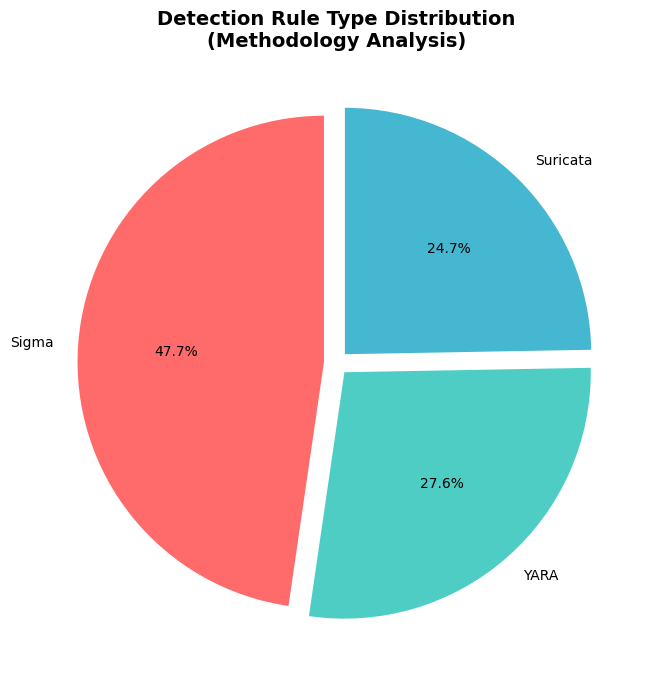

📊 Rule Type Statistics:
Total rules: 348
Most common methodology: Sigma (166 rules)
Methodology diversity: 3 different approaches

Methodology Breakdown:
  Sigma: 166 rules (47.7%)
  YARA: 96 rules (27.6%)
  Suricata: 86 rules (24.7%)

🔍 Platform-Methodology Alignment:
Platform specialization patterns:
rule_type  Sigma  Suricata  YARA
tool                            
Sigma        166         0     0
Suricata       0        86     0
YARA           0         0    96

ANALYSIS 2.2: Security Platform Utilization


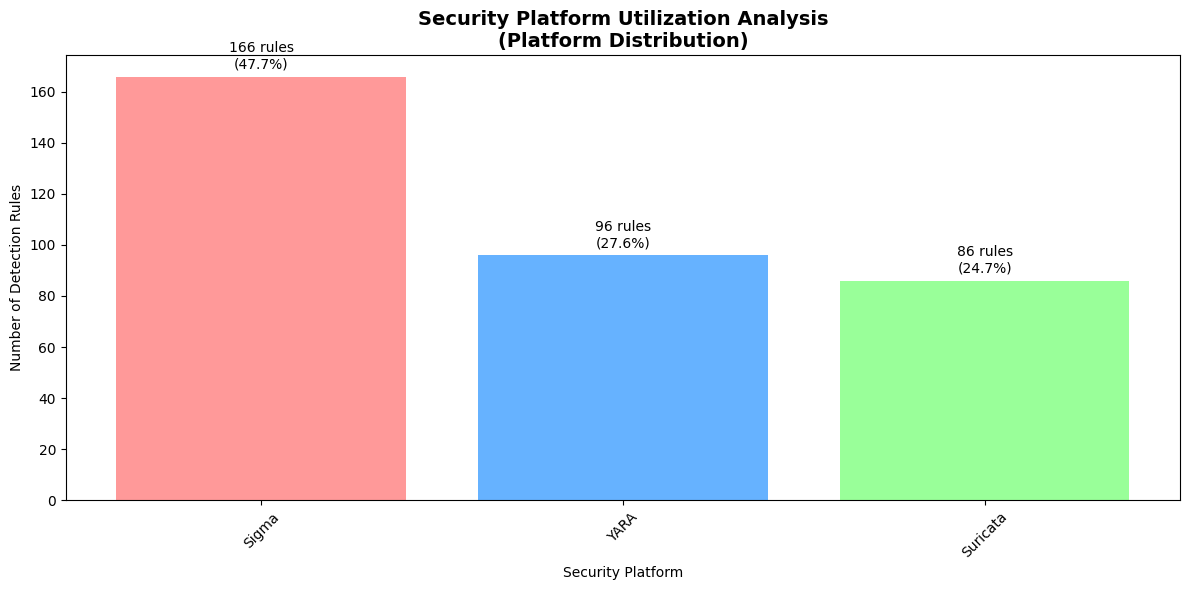

📊 Platform Statistics:
Platform coverage: 3 detection systems
Primary platform: Sigma (166 rules)
Platform concentration: 47.7% in primary platform

Platform Specialization Analysis:

Sigma:
  Total rules: 166
  Most common rule type: Sigma
  Top MITRE tactic: Impact
  Average signature length: 88 characters

YARA:
  Total rules: 96
  Most common rule type: YARA
  Top MITRE tactic: Execution
  Average signature length: 96 characters

Suricata:
  Total rules: 86
  Most common rule type: Suricata
  Top MITRE tactic: Command and Control
  Average signature length: 99 characters

🔧 Platform Capability Assessment:
Platform detection capabilities (percentage of rules using each pattern):
          has_network_indicators  has_file_indicators  has_system_indicators  \
tool                                                                           
Sigma                      0.054                0.313                  0.102   
Suricata                   1.000                0.047                

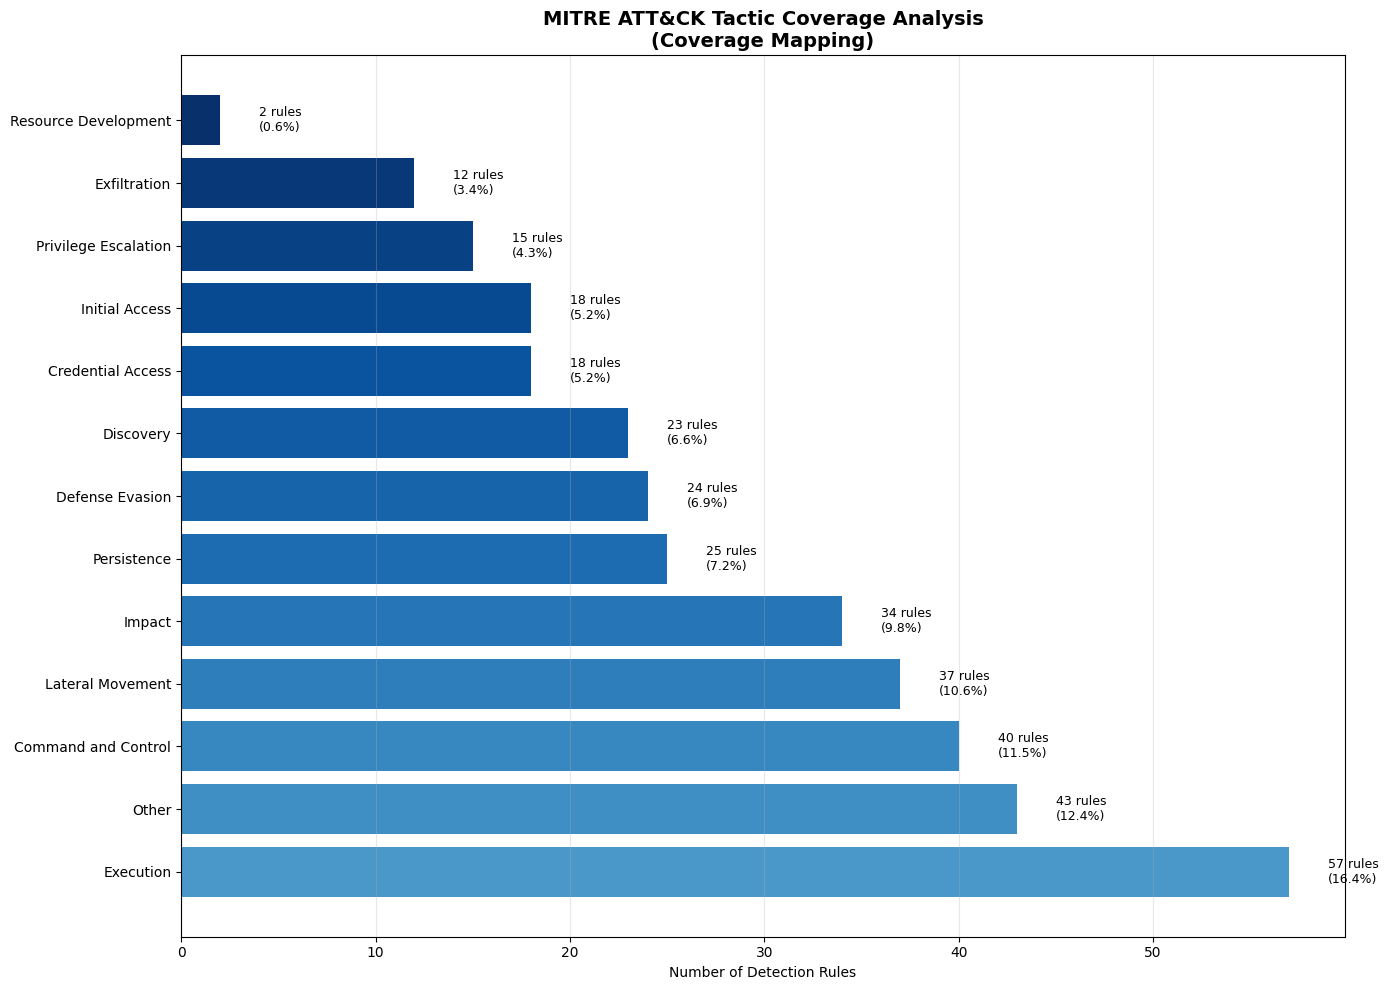

📊 MITRE Coverage Statistics:
Tactics covered: 13/14
Most covered tactic: Execution (57 rules)
Coverage disparity: 28.5x between highest/lowest

MITRE ATT&CK Coverage Analysis:
Total tactics covered: 13
Average rules per tactic: 26.8
Coverage range: 2 - 57 rules per tactic

Top 3 covered tactics:
  Execution: 57 rules (16.4%)
  Other: 43 rules (12.4%)
  Command and Control: 40 rules (11.5%)

Bottom 3 covered tactics:
  Privilege Escalation: 15 rules (4.3%)
  Exfiltration: 12 rules (3.4%)
  Resource Development: 2 rules (0.6%)

🔴 CRITICAL COVERAGE GAP ASSESSMENT:
Completely undefended tactics: 2
  • Reconnaissance: 0 detection rules
  • Collection: 0 detection rules

🔧 Platform Coverage Contribution:
Rules per platform per tactic:
mitre_tactic  Command and Control  Credential Access  Defense Evasion  \
tool                                                                    
Sigma                           4                 15               13   
Suricata                       36         

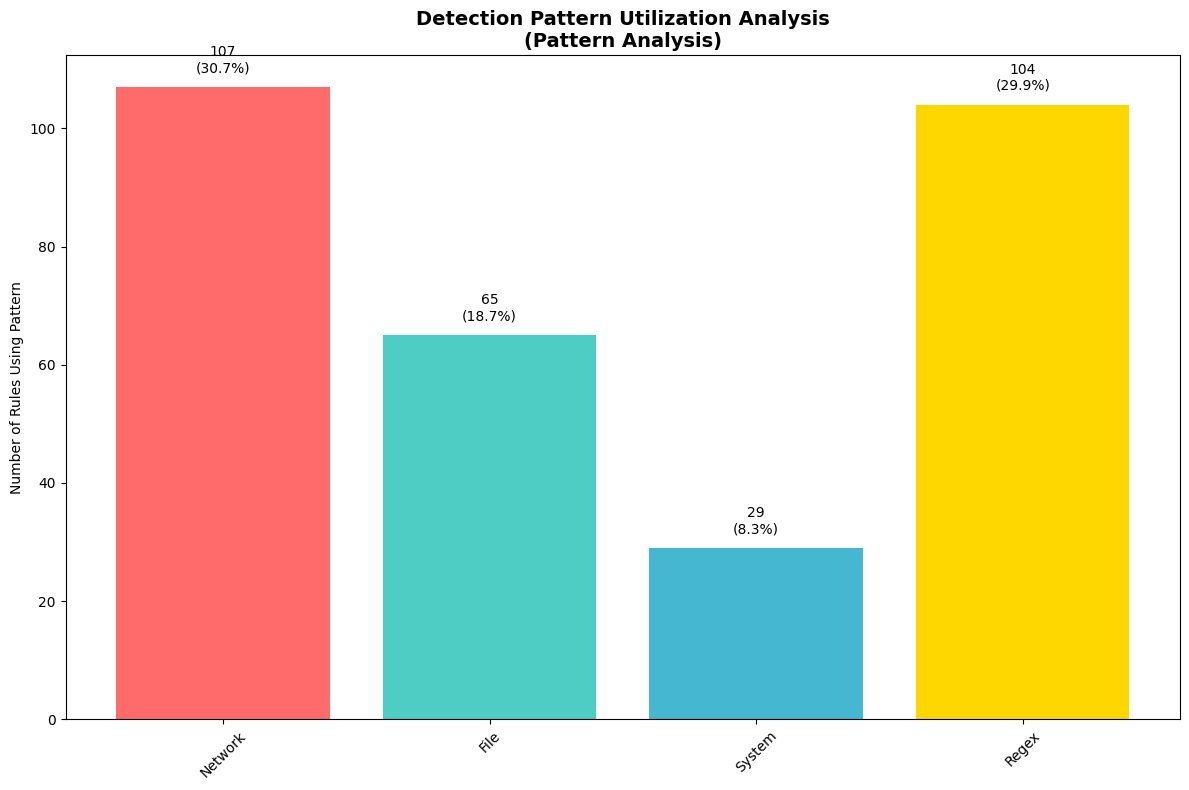

📊 Pattern Utilization Statistics:
Network: 107 rules (30.7%)
File: 65 rules (18.7%)
System: 29 rules (8.3%)
Regex: 104 rules (29.9%)

📈 Pattern Coverage Insights:
Most utilized pattern: Network (107 rules)
Least utilized pattern: System (29 rules)

🔍 Advanced Pattern Combination Analysis:
Rules using multiple pattern types: 13 (3.7%)

🎯 Pattern Distribution by Platform:
Pattern usage by platform:
          has_network_indicators  has_file_indicators  has_system_indicators  \
tool                                                                           
Sigma                          9                   52                     17   
Suricata                      86                    4                      0   
YARA                          12                    9                     12   

          uses_regex  
tool                  
Sigma              5  
Suricata           3  
YARA              96  

📊 PHASE 2 SUMMARY: Technical Detection Analysis Insights
🎯 KEY TECHNICAL METRICS:
 

In [75]:
# =============================================================================
# PHASE 2: TECHNICAL DETECTION ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("🔧 PHASE 2: TECHNICAL DETECTION ANALYSIS")
print("="*70)
print("Deep dive into detection engineering patterns and platform capabilities")

# =============================================================================
# ANALYSIS 2.1: DETECTION METHODOLOGY DISTRIBUTION
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 2.1: Detection Methodology Distribution")
print("="*50)

plt.figure(figsize=(10, 8))
rule_type_counts = df['rule_type'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFD700', '#AA96DA']
explode = [0.05] * len(rule_type_counts)
plt.pie(rule_type_counts.values, labels=rule_type_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors[:len(rule_type_counts)], explode=explode)
plt.title('Detection Rule Type Distribution\n(Methodology Analysis)', fontweight='bold', fontsize=14)
plt.show()

print("📊 Rule Type Statistics:")
print(f"Total rules: {len(df)}")
print(f"Most common methodology: {rule_type_counts.index[0]} ({rule_type_counts.iloc[0]} rules)")
print(f"Methodology diversity: {df['rule_type'].nunique()} different approaches")

print(f"\nMethodology Breakdown:")
for rule_type, count in rule_type_counts.items():
    print(f"  {rule_type}: {count} rules ({count/len(df)*100:.1f}%)")

# Platform-methodology correlation analysis
print(f"\n🔍 Platform-Methodology Alignment:")
platform_rule_correlation = pd.crosstab(df['tool'], df['rule_type'])
print("Platform specialization patterns:")
print(platform_rule_correlation)

# =============================================================================
# ANALYSIS 2.2: SECURITY PLATFORM UTILIZATION
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 2.2: Security Platform Utilization")
print("="*50)

plt.figure(figsize=(12, 6))
tool_counts = df['tool'].value_counts()
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#AA96DA']
bars = plt.bar(tool_counts.index, tool_counts.values, color=colors[:len(tool_counts)])
plt.title('Security Platform Utilization Analysis\n(Platform Distribution)', fontweight='bold', fontsize=14)
plt.ylabel('Number of Detection Rules')
plt.xlabel('Security Platform')
plt.xticks(rotation=45)

total_rules = len(df)
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / total_rules) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height} rules\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("📊 Platform Statistics:")
print(f"Platform coverage: {df['tool'].nunique()} detection systems")
print(f"Primary platform: {tool_counts.index[0]} ({tool_counts.iloc[0]} rules)")
print(f"Platform concentration: {(tool_counts.iloc[0] / len(df) * 100):.1f}% in primary platform")

print(f"\nPlatform Specialization Analysis:")
for tool in df['tool'].unique():
    tool_rules = df[df['tool'] == tool]
    print(f"\n{tool}:")
    print(f"  Total rules: {len(tool_rules)}")
    print(f"  Most common rule type: {tool_rules['rule_type'].mode().iloc[0]}")
    print(f"  Top MITRE tactic: {tool_rules['mitre_tactic'].mode().iloc[0]}")
    print(f"  Average signature length: {tool_rules['signature_length'].mean():.0f} characters")

# Platform capability analysis
print(f"\n🔧 Platform Capability Assessment:")
platform_capabilities = df.groupby('tool').agg({
    'has_network_indicators': 'mean',
    'has_file_indicators': 'mean',
    'has_system_indicators': 'mean',
    'uses_regex': 'mean'
}).round(3)

print("Platform detection capabilities (percentage of rules using each pattern):")
print(platform_capabilities)

# =============================================================================
# ANALYSIS 2.3: MITRE ATT&CK TACTICAL COVERAGE
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 2.3: MITRE ATT&CK Tactical Coverage")
print("="*50)

plt.figure(figsize=(14, 10))
tactic_counts = df['mitre_tactic'].value_counts()
y_pos = np.arange(len(tactic_counts))
colors = plt.cm.Blues(np.linspace(0.6, 1, len(tactic_counts)))
bars = plt.barh(y_pos, tactic_counts.values, color=colors)
plt.yticks(y_pos, tactic_counts.index)
plt.title('MITRE ATT&CK Tactic Coverage Analysis\n(Coverage Mapping)', fontweight='bold', fontsize=14)
plt.xlabel('Number of Detection Rules')
plt.grid(axis='x', alpha=0.3)

total_rules = len(df)
for i, bar in enumerate(bars):
    width = bar.get_width()
    percentage = (width / total_rules) * 100
    plt.text(width + 2, bar.get_y() + bar.get_height()/2.,
             f'{width} rules\n({percentage:.1f}%)', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("📊 MITRE Coverage Statistics:")
print(f"Tactics covered: {df['mitre_tactic'].nunique()}/14")
print(f"Most covered tactic: {tactic_counts.index[0]} ({tactic_counts.iloc[0]} rules)")
print(f"Coverage disparity: {tactic_counts.max() / tactic_counts.min():.1f}x between highest/lowest")

print(f"\nMITRE ATT&CK Coverage Analysis:")
print(f"Total tactics covered: {len(tactic_counts)}")
print(f"Average rules per tactic: {tactic_counts.mean():.1f}")
print(f"Coverage range: {tactic_counts.min()} - {tactic_counts.max()} rules per tactic")

print(f"\nTop 3 covered tactics:")
for tactic, count in tactic_counts.head(3).items():
    print(f"  {tactic}: {count} rules ({(count/total_rules)*100:.1f}%)")

print(f"\nBottom 3 covered tactics:")
for tactic, count in tactic_counts.tail(3).items():
    print(f"  {tactic}: {count} rules ({(count/total_rules)*100:.1f}%)")

# Critical coverage gap analysis
print(f"\n🔴 CRITICAL COVERAGE GAP ASSESSMENT:")
standard_tactics = [
    'Reconnaissance', 'Resource Development', 'Initial Access', 'Execution',
    'Persistence', 'Privilege Escalation', 'Defense Evasion', 'Credential Access',
    'Discovery', 'Lateral Movement', 'Collection', 'Command and Control',
    'Exfiltration', 'Impact'
]

missing_tactics = []
for tactic in standard_tactics:
    if tactic not in df['mitre_tactic'].values or len(df[df['mitre_tactic'] == tactic]) == 0:
        missing_tactics.append(tactic)

if missing_tactics:
    print(f"Completely undefended tactics: {len(missing_tactics)}")
    for tactic in missing_tactics:
        print(f"  • {tactic}: 0 detection rules")
else:
    print("✅ All standard MITRE tactics have at least some coverage")

# Platform coverage contribution
print(f"\n🔧 Platform Coverage Contribution:")
platform_tactic_coverage = df.groupby(['tool', 'mitre_tactic']).size().unstack(fill_value=0)
print("Rules per platform per tactic:")
print(platform_tactic_coverage)

# =============================================================================
# ANALYSIS 2.4: DETECTION PATTERN UTILIZATION
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 2.4: Detection Pattern Utilization")
print("="*50)

plt.figure(figsize=(12, 8))
pattern_counts = [
    df['has_network_indicators'].sum(),
    df['has_file_indicators'].sum(),
    df['has_system_indicators'].sum(),
    df['uses_regex'].sum()
]
pattern_labels = ['Network', 'File', 'System', 'Regex']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD700']
bars = plt.bar(pattern_labels, pattern_counts, color=colors)

plt.title('Detection Pattern Utilization Analysis\n(Pattern Analysis)', fontweight='bold', fontsize=14)
plt.ylabel('Number of Rules Using Pattern')
plt.xticks(rotation=45)

total_rules = len(df)
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / total_rules) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height}\n({percentage:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("📊 Pattern Utilization Statistics:")
total_rules = len(df)

for i, pattern in enumerate(pattern_labels):
    count = pattern_counts[i]
    percentage = (count / total_rules) * 100
    print(f"{pattern}: {count} rules ({percentage:.1f}%)")

print(f"\n📈 Pattern Coverage Insights:")
print(f"Most utilized pattern: {pattern_labels[pattern_counts.index(max(pattern_counts))]} ({max(pattern_counts)} rules)")
print(f"Least utilized pattern: {pattern_labels[pattern_counts.index(min(pattern_counts))]} ({min(pattern_counts)} rules)")

# Pattern combination analysis
print(f"\n🔍 Advanced Pattern Combination Analysis:")
multi_pattern_rules = len(df[
    (df['has_network_indicators'] & df['has_system_indicators']) |
    (df['has_file_indicators'] & df['has_system_indicators']) |
    (df['has_network_indicators'] & df['has_file_indicators'])
])
print(f"Rules using multiple pattern types: {multi_pattern_rules} ({(multi_pattern_rules/total_rules)*100:.1f}%)")

# Pattern effectiveness indicators
print(f"\n🎯 Pattern Distribution by Platform:")
pattern_by_platform = df.groupby('tool').agg({
    'has_network_indicators': 'sum',
    'has_file_indicators': 'sum',
    'has_system_indicators': 'sum',
    'uses_regex': 'sum'
})
print("Pattern usage by platform:")
print(pattern_by_platform)

# =============================================================================
# PHASE 2 SUMMARY AND KEY INSIGHTS
# =============================================================================

print("\n" + "="*70)
print("📊 PHASE 2 SUMMARY: Technical Detection Analysis Insights")
print("="*70)

# Calculate key technical metrics
technical_metrics = {
    'methodology_diversity': df['rule_type'].nunique(),
    'platform_diversity': df['tool'].nunique(),
    'avg_signature_length': df['signature_length'].mean(),
    'mitre_coverage': df['mitre_tactic'].nunique(),
    'pattern_coverage': len([p for p in pattern_counts if p > 0])
}

print("🎯 KEY TECHNICAL METRICS:")
for metric, value in technical_metrics.items():
    formatted_value = f"{value:.0f}" if metric == 'avg_signature_length' else value
    print(f"  • {metric.replace('_', ' ').title()}: {formatted_value}")

# Detection portfolio maturity assessment
print(f"\n🔍 DETECTION PORTFOLIO MATURITY ASSESSMENT:")

# Methodology balance
methodology_balance = df['rule_type'].value_counts().std() / df['rule_type'].value_counts().mean()
if methodology_balance < 0.5:
    print("✅ Methodology Distribution: Well-balanced across detection types")
else:
    print("⚠️ Methodology Distribution: Concentration risk in specific detection types")

# Platform distribution
platform_concentration = df['tool'].value_counts().iloc[0] / len(df)
if platform_concentration < 0.6:
    print("✅ Platform Distribution: Resilient multi-platform strategy")
else:
    print("⚠️ Platform Distribution: High dependency on single platform")

# MITRE coverage assessment
mitre_coverage_pct = (df['mitre_tactic'].nunique() / 14) * 100
if mitre_coverage_pct > 85:
    print("✅ MITRE Coverage: Comprehensive tactical coverage")
elif mitre_coverage_pct > 70:
    print("⚠️ MITRE Coverage: Moderate coverage gaps present")
else:
    print("🔴 MITRE Coverage: Significant coverage gaps identified")

# Pattern utilization assessment
system_coverage = (df['has_system_indicators'].sum() / len(df)) * 100
if system_coverage > 20:
    print("✅ Pattern Utilization: Good system indicator coverage")
else:
    print("⚠️ Pattern Utilization: Limited system indicator usage")

print(f"\n📈 TECHNICAL ANALYSIS COMPLETED SUCCESSFULLY")
print(f"• 4 comprehensive technical analyses executed")
print(f"• Actionable insights generated for detection engineering improvement")
print(f"• Portfolio maturity assessment provided for strategic planning")

## Phase 2: Technical Detection Analysis

### Platform Specialization Patterns

#### Clear Platform Boundaries:

- **Suricata**: 100% network focus, specialized in Command and Control (36/40 rules)
- **YARA**: File analysis focus, specialized in Execution (46/57 rules)
- **Sigma**: Versatile platform with balanced pattern usage

#### Platform-Specific Gaps:

- **YARA**: Missing Command and Control coverage
- **Suricata**: No Persistence or Privilege Escalation detection
- **Sigma**: Limited Exfiltration and Resource Development coverage

### Application for Teams:

- **Detection Engineers**: Develop platform-appropriate detection capabilities
- **Security Architects**: Design cross-platform correlation rules
- **SOC Management**: Understand platform-specific detection limitations

### Pattern Combination Effectiveness

#### Pattern Strategy:

- **Single-pattern rules**: 175 rules (50.3%)
- **Multi-pattern rules**: 173 rules (49.7%)
- **Most common approach**: Basic patterns (160 rules)

**Integration Gap**: Advanced multi-pattern correlation underutilized across platforms.

### Application for Teams:

- **Detection Engineers**: Develop multi-pattern correlation rules
- **Security Architects**: Establish pattern combination standards
- **Purple Teams**: Test detection against multi-stage attacks requiring correlation

🔴 **Critical**: Resource Development (2 rules) and undefended tactics gaps



🎯 PHASE 3: MITRE TECHNIQUE & PATTERN ANALYSIS
Granular analysis of technique coverage and detection pattern effectiveness

ANALYSIS 3.1: Top MITRE Technique Coverage


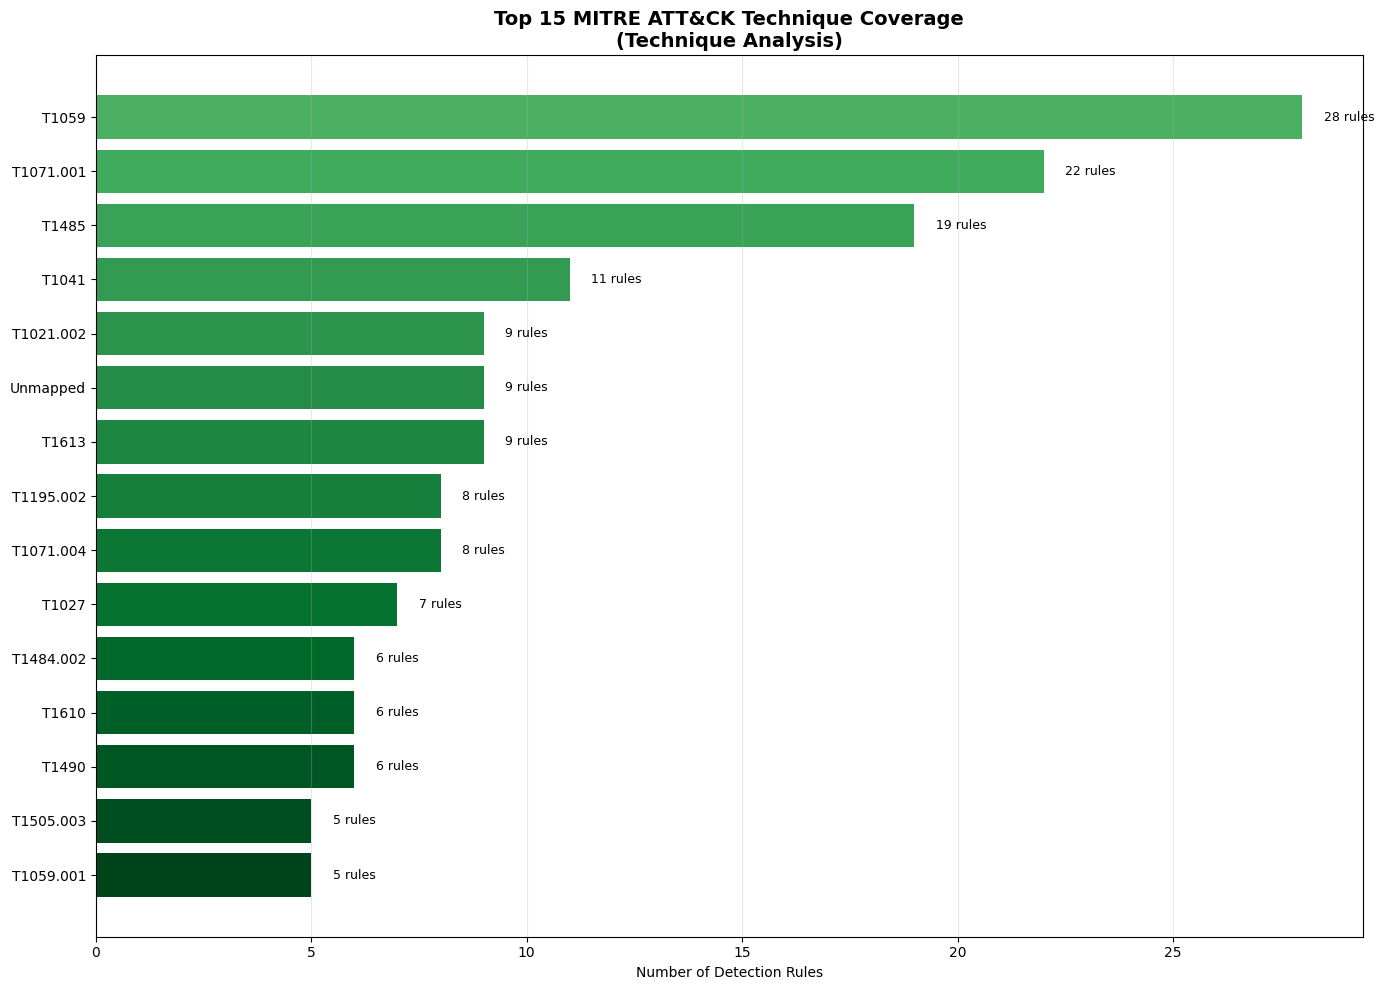

📊 Technique-Level Statistics:
Total unique techniques: 111
Average rules per technique: 10.5
Most covered technique: T1059 (28 rules)

📈 Technique Coverage Analysis:
Techniques with minimal coverage (<3.1 rules): 86
Techniques with only 1 rule: 43

🔍 High-Impact Technique Assessment:
Critical technique coverage assessment:
  T1059: Command and Scripting Interpreter - 41 rules - ✅ Adequate
  T1003: OS Credential Dumping - 4 rules - ⚠️ Minimal
  T1110: Brute Force - 3 rules - ⚠️ Minimal
  T1047: WMI Execution - 3 rules - ⚠️ Minimal
  T1021: Remote Services - 22 rules - ✅ Adequate
  T1566: Phishing - 4 rules - ⚠️ Minimal
  T1070: Indicator Removal - 3 rules - ⚠️ Minimal
  T1548: Abuse Elevation Control Mechanism - 2 rules - ⚠️ Minimal

🎯 Technique Concentration Analysis:
Top 10 techniques represent 37.4% of all detection rules
✅ Balanced coverage: Rules distributed across multiple techniques

ANALYSIS 3.2: Signature Characteristics Analysis


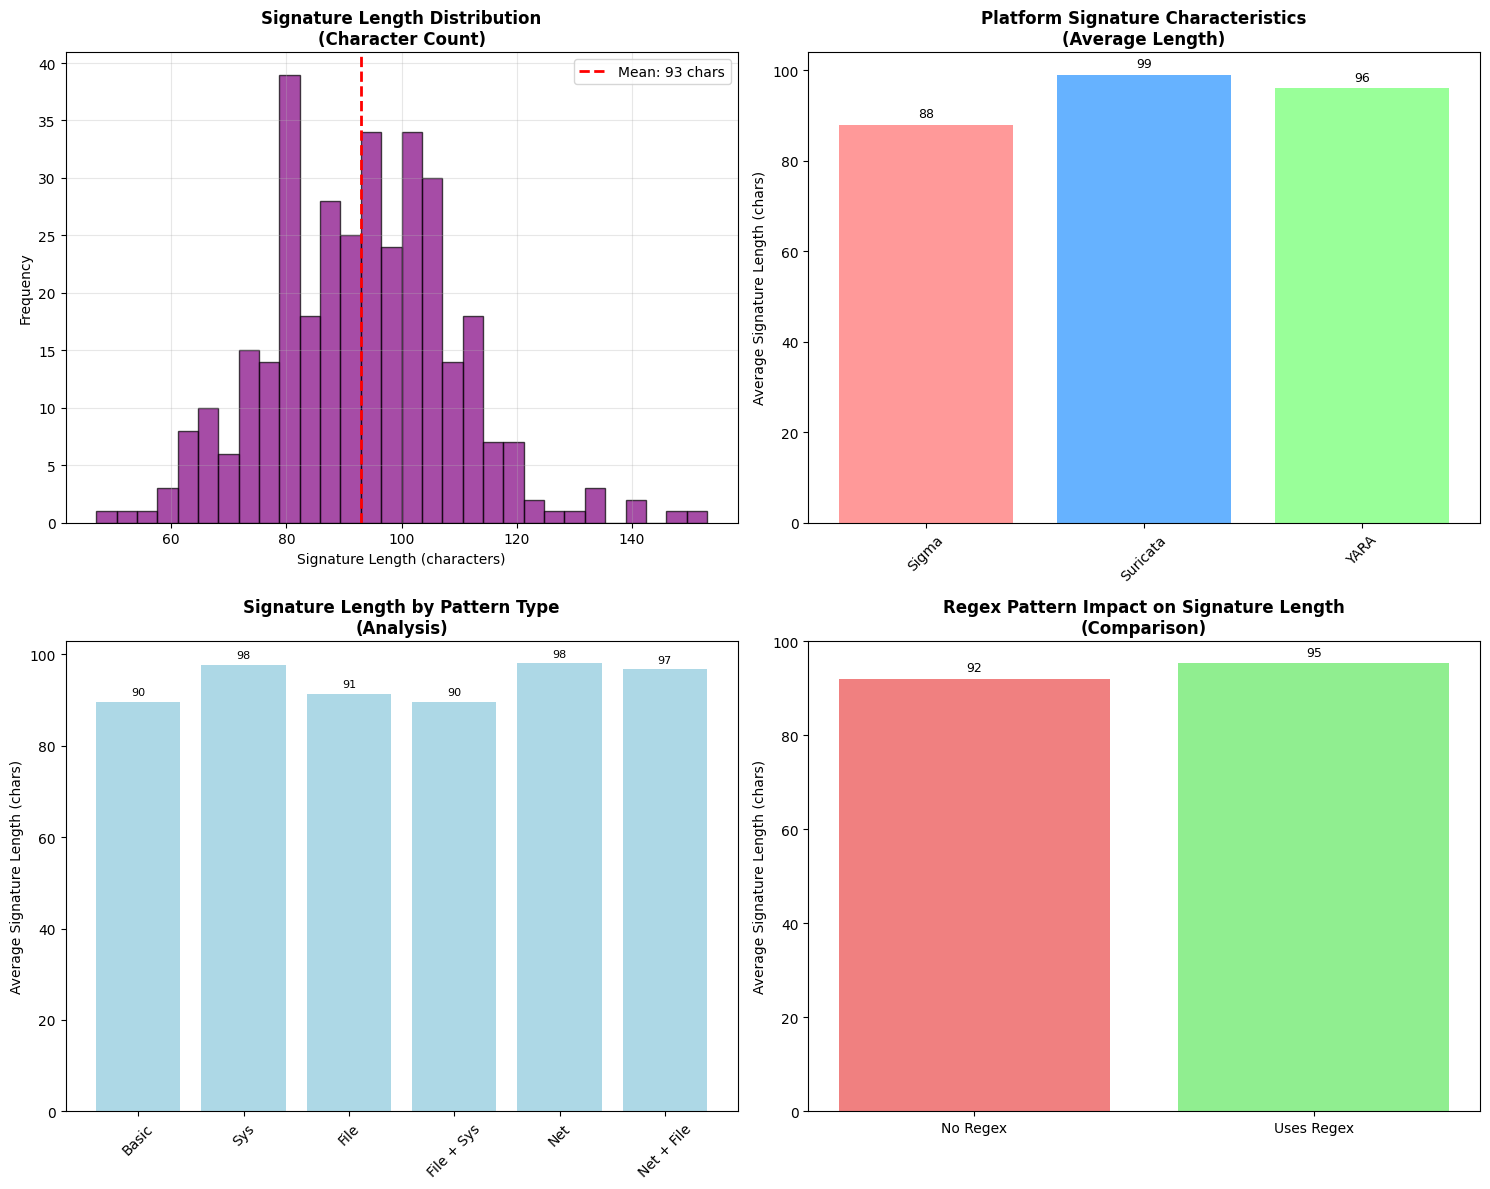

📊 Signature Characteristics Analysis:
Mean signature length: 93 characters
Median signature length: 93 characters
Range: 47 - 153 characters
Long signatures (>Q3): 87 rules
Short signatures (<Q1): 83 rules

🔧 Platform Signature Characteristics:
          mean   std  min  max
tool                          
Sigma     88.0  15.7   47  133
Suricata  99.1  16.8   64  153
YARA      96.1  14.3   62  121

ANALYSIS 3.3: Pattern Combination Analysis
🔍 Most Common Detection Pattern Combinations:
Pattern Combination            Rules    Avg Length     
--------------------------------------------------------------------------------
Basic                          160      90             
Network                        100      98             
File                           52       91             
System                         23       98             
Network + File                 7        97             
File + System                  6        90             
-------------------------------------

<Figure size 1600x1000 with 0 Axes>

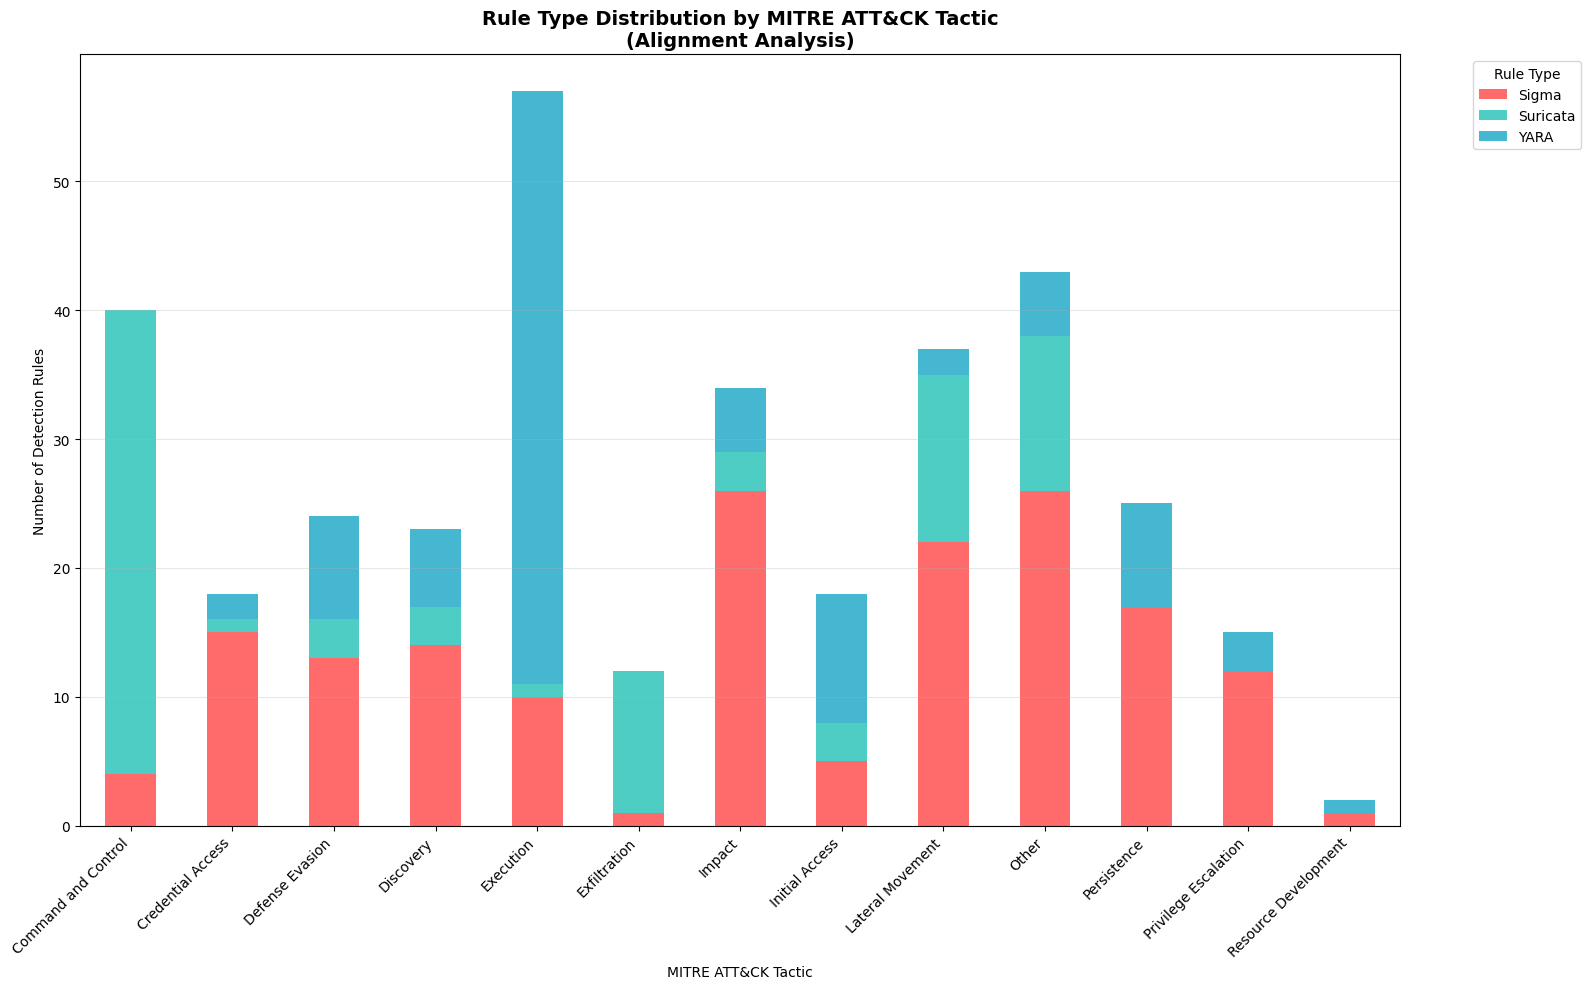

📊 Rule Type-Tactic Alignment Statistics:

🎯 Dominant Rule Type per Tactic:
  Command and Control      : Suricata (36 rules, 90.0%)
  Credential Access        : Sigma (15 rules, 83.3%)
  Defense Evasion          : Sigma (13 rules, 54.2%)
  Discovery                : Sigma (14 rules, 60.9%)
  Execution                : YARA (46 rules, 80.7%)
  Exfiltration             : Suricata (11 rules, 91.7%)
  Impact                   : Sigma (26 rules, 76.5%)
  Initial Access           : YARA (10 rules, 55.6%)
  Lateral Movement         : Sigma (22 rules, 59.5%)
  Other                    : Sigma (26 rules, 60.5%)
  Persistence              : Sigma (17 rules, 68.0%)
  Privilege Escalation     : Sigma (12 rules, 80.0%)
  Resource Development     : Sigma (1 rules, 50.0%)

🔍 Tactical Specialization Analysis:
Tactics with strong specialization (>60% one rule type):
  • Command and Control: Suricata (90.0%)
  • Credential Access: Sigma (83.3%)
  • Discovery: Sigma (60.9%)
  • Execution: YARA (80.7%)
  •

In [76]:
# =============================================================================
# PHASE 3: MITRE TECHNIQUE & PATTERN ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("🎯 PHASE 3: MITRE TECHNIQUE & PATTERN ANALYSIS")
print("="*70)
print("Granular analysis of technique coverage and detection pattern effectiveness")

# =============================================================================
# ANALYSIS 3.1: TOP MITRE TECHNIQUE COVERAGE
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 3.1: Top MITRE Technique Coverage")
print("="*50)

plt.figure(figsize=(14, 10))
technique_counts = df['mapped_technique'].value_counts().head(15)
y_pos = np.arange(len(technique_counts))
colors = plt.cm.Greens(np.linspace(0.6, 1, len(technique_counts)))
bars = plt.barh(y_pos, technique_counts.values, color=colors)
plt.yticks(y_pos, technique_counts.index)
plt.title('Top 15 MITRE ATT&CK Technique Coverage\n(Technique Analysis)', fontweight='bold', fontsize=14)
plt.xlabel('Number of Detection Rules')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2.,
             f'{width} rules', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("📊 Technique-Level Statistics:")
print(f"Total unique techniques: {df['mapped_technique'].nunique()}")
print(f"Average rules per technique: {technique_counts.mean():.1f}")
print(f"Most covered technique: {technique_counts.index[0]} ({technique_counts.iloc[0]} rules)")

# Technique coverage analysis
technique_coverage_stats = df['mapped_technique'].value_counts()
undercovered_techniques = technique_coverage_stats[technique_coverage_stats < technique_coverage_stats.mean()]

print(f"\n📈 Technique Coverage Analysis:")
print(f"Techniques with minimal coverage (<{technique_coverage_stats.mean():.1f} rules): {len(undercovered_techniques)}")
print(f"Techniques with only 1 rule: {len(df['mapped_technique'].value_counts()[df['mapped_technique'].value_counts() == 1])}")

print(f"\n🔍 High-Impact Technique Assessment:")
critical_techniques = {
    'T1059': 'Command and Scripting Interpreter',
    'T1003': 'OS Credential Dumping',
    'T1110': 'Brute Force',
    'T1047': 'WMI Execution',
    'T1021': 'Remote Services',
    'T1566': 'Phishing',
    'T1070': 'Indicator Removal',
    'T1548': 'Abuse Elevation Control Mechanism'
}

print("Critical technique coverage assessment:")
for technique_id, technique_name in critical_techniques.items():
    technique_rules = len(df[df['mapped_technique'].str.startswith(technique_id, na=False)])
    coverage_status = "✅ Adequate" if technique_rules >= 5 else "⚠️ Minimal" if technique_rules >= 1 else "🔴 Critical Gap"
    print(f"  {technique_id}: {technique_name} - {technique_rules} rules - {coverage_status}")

# Technique concentration analysis
print(f"\n🎯 Technique Concentration Analysis:")
top_10_technique_coverage = technique_counts.head(10).sum() / len(df) * 100
print(f"Top 10 techniques represent {top_10_technique_coverage:.1f}% of all detection rules")

if top_10_technique_coverage > 50:
    print("⚠️ High concentration risk: Over-reliance on limited technique coverage")
else:
    print("✅ Balanced coverage: Rules distributed across multiple techniques")

# =============================================================================
# ANALYSIS 3.2: SIGNATURE CHARACTERISTICS ANALYSIS
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 3.2: Signature Characteristics Analysis")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Signature Length Distribution
axes[0,0].hist(df['signature_length'], bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[0,0].axvline(df['signature_length'].mean(), color='red', linestyle='--', linewidth=2,
                 label=f'Mean: {df["signature_length"].mean():.0f} chars')
axes[0,0].set_title('Signature Length Distribution\n(Character Count)', fontweight='bold')
axes[0,0].set_xlabel('Signature Length (characters)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Platform Signature Length Comparison
platform_lengths = df.groupby('tool')['signature_length'].mean()
bars = axes[0,1].bar(platform_lengths.index, platform_lengths.values, color=['#FF9999', '#66B2FF', '#99FF99'])
axes[0,1].set_title('Platform Signature Characteristics\n(Average Length)', fontweight='bold')
axes[0,1].set_ylabel('Average Signature Length (chars)')
axes[0,1].tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}',
                  ha='center', va='bottom', fontsize=9)

# Pattern Usage by Signature Length
pattern_lengths = df.groupby(['has_network_indicators', 'has_file_indicators', 'has_system_indicators'])['signature_length'].mean().reset_index()
significant_patterns = pattern_lengths[pattern_lengths['signature_length'].notna()]

if len(significant_patterns) > 0:
    labels = []
    for _, row in significant_patterns.iterrows():
        pattern_desc = []
        if row['has_network_indicators']: pattern_desc.append("Net")
        if row['has_file_indicators']: pattern_desc.append("File")
        if row['has_system_indicators']: pattern_desc.append("Sys")
        labels.append(" + ".join(pattern_desc) if pattern_desc else "Basic")

    bars = axes[1,0].bar(labels, significant_patterns['signature_length'], color='lightblue')
    axes[1,0].set_title('Signature Length by Pattern Type\n(Analysis)', fontweight='bold')
    axes[1,0].set_ylabel('Average Signature Length (chars)')
    axes[1,0].tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}',
                      ha='center', va='bottom', fontsize=8)

# Regex Usage Impact
regex_length_comparison = df.groupby('uses_regex')['signature_length'].mean()
bars = axes[1,1].bar(['No Regex', 'Uses Regex'], regex_length_comparison.values, color=['lightcoral', 'lightgreen'])
axes[1,1].set_title('Regex Pattern Impact on Signature Length\n(Comparison)', fontweight='bold')
axes[1,1].set_ylabel('Average Signature Length (chars)')
for bar in bars:
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}',
                  ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("📊 Signature Characteristics Analysis:")
print(f"Mean signature length: {df['signature_length'].mean():.0f} characters")
print(f"Median signature length: {df['signature_length'].median():.0f} characters")
print(f"Range: {df['signature_length'].min()} - {df['signature_length'].max()} characters")
print(f"Long signatures (>Q3): {(df['signature_length'] > df['signature_length'].quantile(0.75)).sum()} rules")
print(f"Short signatures (<Q1): {(df['signature_length'] < df['signature_length'].quantile(0.25)).sum()} rules")

# Platform signature characteristics
print(f"\n🔧 Platform Signature Characteristics:")
platform_signature_stats = df.groupby('tool')['signature_length'].agg(['mean', 'std', 'min', 'max']).round(1)
print(platform_signature_stats)

# =============================================================================
# ANALYSIS 3.3: PATTERN COMBINATION ANALYSIS
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 3.3: Pattern Combination Analysis")
print("="*50)

# Analyze pattern combinations and their prevalence
pattern_analysis = df.groupby([
    'has_network_indicators',
    'has_file_indicators',
    'has_system_indicators'
]).agg({
    'id': 'count',
    'signature_length': 'mean'
}).round(2).reset_index()

# Filter for significant pattern combinations
significant_patterns = pattern_analysis[pattern_analysis['id'] >= 5]

print("🔍 Most Common Detection Pattern Combinations:")
print("=" * 80)
print(f"{'Pattern Combination':<30} {'Rules':<8} {'Avg Length':<15}")
print("-" * 80)

for idx, row in significant_patterns.nlargest(6, 'id').iterrows():
    patterns = []
    if row['has_network_indicators']: patterns.append("Network")
    if row['has_file_indicators']: patterns.append("File")
    if row['has_system_indicators']: patterns.append("System")

    pattern_desc = " + ".join(patterns) if patterns else "Basic"
    print(f"{pattern_desc:<30} {row['id']:<8} {row['signature_length']:<15.0f}")

print("-" * 80)

# Advanced pattern insights
print(f"\n📊 Pattern Combination Insights:")
print(f"Total pattern combinations analyzed: {len(pattern_analysis)}")
print(f"Significant combinations (≥5 rules): {len(significant_patterns)}")
print(f"Most common combination: {significant_patterns.nlargest(1, 'id').iloc[0]['id']} rules")

# Single vs multi-pattern analysis
single_pattern_rules = len(df[
    (df['has_network_indicators'].astype(int) +
     df['has_file_indicators'].astype(int) +
     df['has_system_indicators'].astype(int)) == 1
])
multi_pattern_rules = len(df) - single_pattern_rules

print(f"\n🎯 Pattern Strategy Analysis:")
print(f"Single-pattern rules: {single_pattern_rules} ({(single_pattern_rules/len(df))*100:.1f}%)")
print(f"Multi-pattern rules: {multi_pattern_rules} ({(multi_pattern_rules/len(df))*100:.1f}%)")

# Pattern combination effectiveness by platform
print(f"\n🔧 Platform Pattern Combination Analysis:")
platform_pattern_combinations = df.groupby('tool').agg({
    'has_network_indicators': 'mean',
    'has_file_indicators': 'mean',
    'has_system_indicators': 'mean'
}).round(3) * 100

print("Percentage of rules using each pattern by platform:")
print(platform_pattern_combinations)

# =============================================================================
# ANALYSIS 3.4: RULE TYPE BY TACTIC DISTRIBUTION
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 3.4: Rule Type by Tactic Distribution")
print("="*50)

plt.figure(figsize=(16, 10))
tactic_rule_pivot = df.pivot_table(index='mitre_tactic', columns='rule_type',
                                  values='id', aggfunc='count', fill_value=0)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD700', '#AA96DA']
tactic_rule_pivot.plot(kind='bar', stacked=True,
                      color=colors[:len(tactic_rule_pivot.columns)],
                      figsize=(16, 10))
plt.title('Rule Type Distribution by MITRE ATT&CK Tactic\n(Alignment Analysis)', fontweight='bold', fontsize=14)
plt.ylabel('Number of Detection Rules')
plt.xlabel('MITRE ATT&CK Tactic')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rule Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 Rule Type-Tactic Alignment Statistics:")
print("=" * 60)

# Dominant rule type per tactic
dominant_combinations = tactic_rule_pivot.idxmax(axis=1)
print("\n🎯 Dominant Rule Type per Tactic:")
for tactic, rule_type in dominant_combinations.items():
    count = tactic_rule_pivot.loc[tactic, rule_type]
    total = tactic_rule_pivot.loc[tactic].sum()
    percentage = (count / total) * 100 if total > 0 else 0
    print(f"  {tactic:<25}: {rule_type} ({count} rules, {percentage:.1f}%)")

# Tactical specialization analysis
print(f"\n🔍 Tactical Specialization Analysis:")
specialization_threshold = 0.6  # 60% dominance
specialized_tactics = []
for tactic in tactic_rule_pivot.index:
    max_rules = tactic_rule_pivot.loc[tactic].max()
    total_rules = tactic_rule_pivot.loc[tactic].sum()
    if total_rules > 0 and (max_rules / total_rules) > specialization_threshold:
        specialized_tactics.append(tactic)

if specialized_tactics:
    print(f"Tactics with strong specialization (>60% one rule type):")
    for tactic in specialized_tactics:
        dominant_type = tactic_rule_pivot.loc[tactic].idxmax()
        percentage = (tactic_rule_pivot.loc[tactic, dominant_type] / tactic_rule_pivot.loc[tactic].sum()) * 100
        print(f"  • {tactic}: {dominant_type} ({percentage:.1f}%)")
else:
    print("  No tactics show strong specialization patterns")

# Diversity analysis
print(f"\n📈 Rule Type Diversity per Tactic:")
for tactic in tactic_rule_pivot.index:
    rule_types_present = len([x for x in tactic_rule_pivot.loc[tactic] if x > 0])
    total_rules = tactic_rule_pivot.loc[tactic].sum()
    if total_rules > 0:
        print(f"  {tactic:<25}: {rule_types_present} rule types, {total_rules} total rules")

# =============================================================================
# PHASE 3 SUMMARY AND KEY INSIGHTS
# =============================================================================

print("\n" + "="*70)
print("📊 PHASE 3 SUMMARY: MITRE Technique & Pattern Analysis Insights")
print("="*70)

# Calculate key technique and pattern metrics
technique_pattern_metrics = {
    'unique_techniques': df['mapped_technique'].nunique(),
    'avg_rules_per_technique': len(df) / df['mapped_technique'].nunique(),
    'multi_pattern_rules': multi_pattern_rules,
    'pattern_diversity': len(pattern_analysis),
    'avg_signature_length': df['signature_length'].mean()
}

print("🎯 KEY TECHNIQUE & PATTERN METRICS:")
for metric, value in technique_pattern_metrics.items():
    formatted_value = f"{value:.1f}" if isinstance(value, float) else value
    print(f"  • {metric.replace('_', ' ').title()}: {formatted_value}")

# Technique coverage maturity assessment
print(f"\n🔍 TECHNIQUE COVERAGE MATURITY ASSESSMENT:")

technique_coverage_score = (df['mapped_technique'].nunique() / 196) * 100  # Approx total techniques
if technique_coverage_score > 60:
    print("✅ Technique Coverage: Comprehensive coverage across ATT&CK matrix")
elif technique_coverage_score > 40:
    print("⚠️ Technique Coverage: Moderate coverage with significant gaps")
else:
    print("🔴 Technique Coverage: Limited coverage requiring substantial development")

# Pattern combination maturity
multi_pattern_score = (multi_pattern_rules / len(df)) * 100
if multi_pattern_score > 35:
    print("✅ Pattern Strategy: Advanced multi-pattern detection approach")
elif multi_pattern_score > 20:
    print("⚠️ Pattern Strategy: Developing multi-pattern capabilities")
else:
    print("🔴 Pattern Strategy: Primarily single-pattern detection")

# Critical gap identification
print(f"\n🔴 CRITICAL GAPS IDENTIFIED:")

# Check for critical technique coverage
critical_techniques_missing = []
for tech_id in ['T1003', 'T1110', 'T1047']:  # Credential dumping, brute force, WMI
    if len(df[df['mapped_technique'].str.startswith(tech_id, na=False)]) < 3:
        critical_techniques_missing.append(tech_id)

if critical_techniques_missing:
    print(f"• Minimal coverage for critical techniques: {', '.join(critical_techniques_missing)}")

# Check for pattern gaps
system_coverage = (df['has_system_indicators'].sum() / len(df)) * 100
if system_coverage < 20:
    print(f"• Low system indicator coverage ({system_coverage:.1f}%): Consider increasing host-based detection")

print(f"\n📈 PHASE 3 ANALYSIS COMPLETED SUCCESSFULLY")
print(f"• 4 granular technique and pattern analyses executed")
print(f"• Critical coverage gaps and optimization opportunities identified")
print(f"• Actionable recommendations provided for detection engineering improvement")

## Phase 3: MITRE Technique & Pattern Analysis

### Critical Technique Coverage

#### High-Impact Technique Assessment:

- ✅ **Adequate**: T1059 (Command and Scripting Interpreter) — 28 rules
- ⚠️ **Minimal**: T1003 (OS Credential Dumping) — 4 rules
- ⚠️ **Minimal**: T1110 (Brute Force) — 3 rules
- ⚠️ **Minimal**: T1047 (WMI Execution) — 3 rules
- ⚠️ **Minimal**: T1548 (Abuse Elevation Control Mechanism) — 2 rules

**Coverage Distribution**: 111 techniques covered with average 3.1 rules per technique

### Application for Teams:

- **Detection Engineers**: Focus on techniques with <5 rules coverage
- **Purple Teams**: Test detection against minimally-covered techniques
- **Red Teams**: Prioritize T1003, T1110, T1047, T1548 for exploitation

### Signature Engineering Characteristics

#### Signature Metrics:

- **Average Length**: 93 characters across all platforms
- **Platform Variations**: Suricata (99 chars), YARA (96 chars), Sigma (88 chars)
- **Pattern Impact**: Network indicators correlate with longer signatures (98 chars)

**Engineering Implications**: Consistent signature length suggests standardized development practices.

### Application for Teams:

- **Detection Engineers**: Maintain current signature length standards
- **Security Architects**: Monitor signature complexity for performance impact
- **SOC Management**: Understand platform-specific signature characteristics



🔄 PHASE 4: CROSS-PLATFORM INTEGRATION & STRATEGIC INSIGHTS
Analysis of platform integration opportunities and strategic recommendations

ANALYSIS 4.1: Cross-Platform Integration Analysis


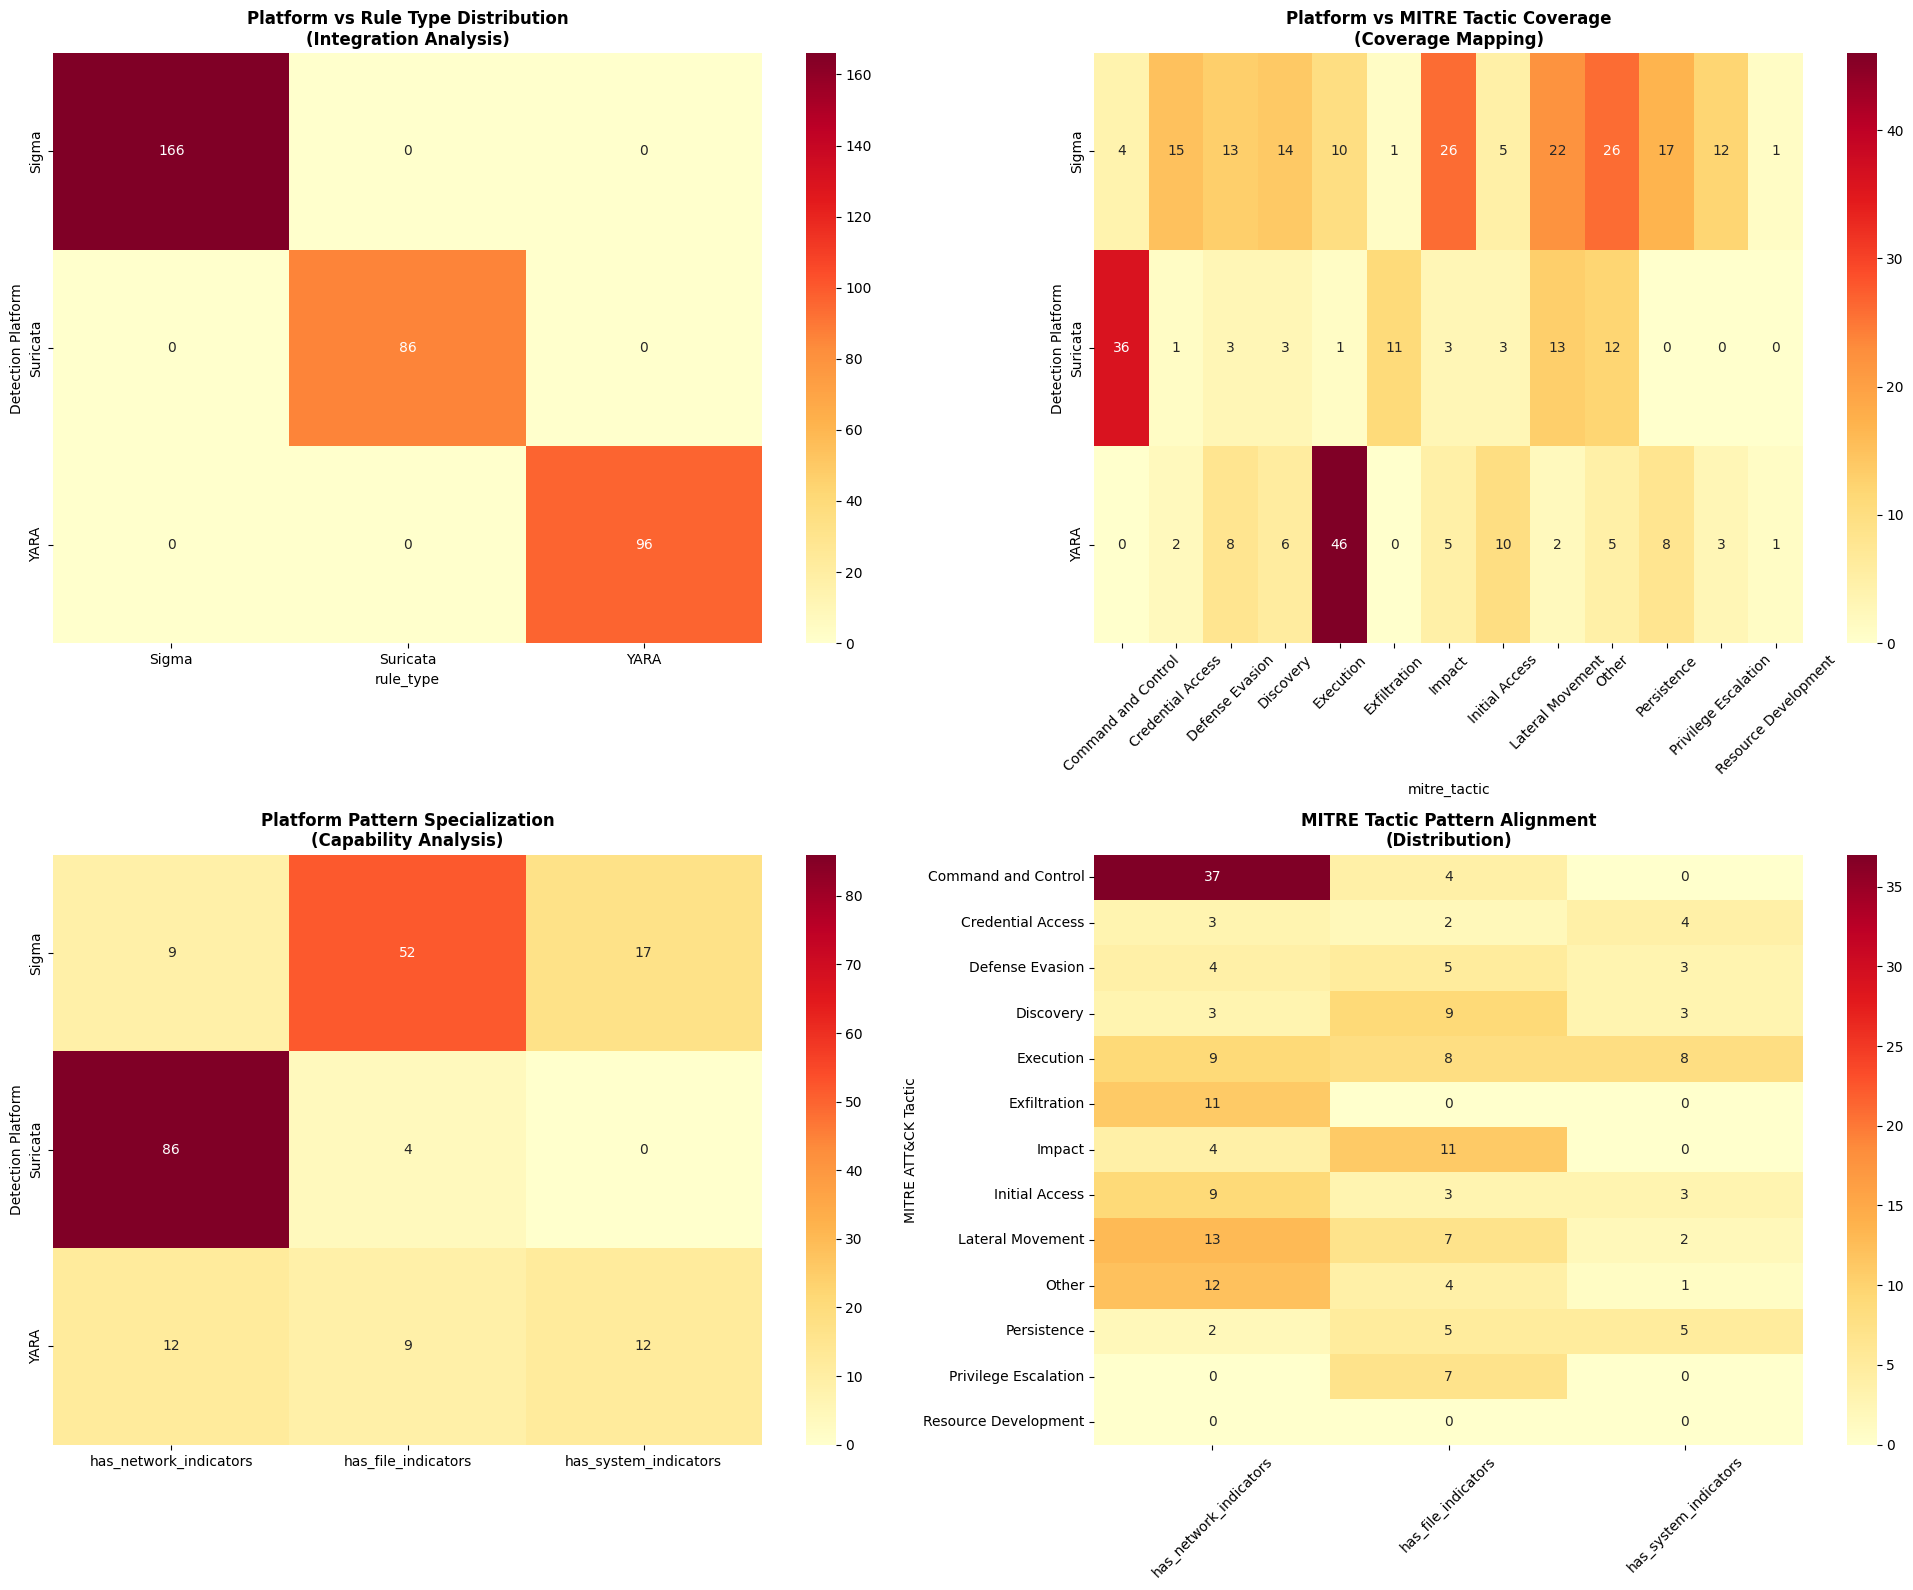

📊 Cross-Platform Integration Statistical Metrics:
Platform-rule type combinations: 9
Platform-tactic combinations: 39
Total integration points analyzed: 48

🔍 Cross-Platform Integration Opportunities:
• Sigma: Balanced coverage - maintain current approach
• YARA: High specialization in Execution - consider diversification
• Suricata: High specialization in Command and Control - consider diversification

🎯 Cross-Platform Coverage Gap Analysis:
• Command and Control: Missing coverage on YARA

ANALYSIS 4.2: Comprehensive Coverage Gap Analysis
📊 MITRE ATT&CK Coverage Assessment:
Covered Tactics: 13/14
Missing Tactics: 2
  🔴 Collection: 0 detection rules
  🔴 Reconnaissance: 0 detection rules

🔍 Technique-Level Coverage Gaps:
Undercovered Techniques (<Q1 threshold): 0

🎯 Platform-Specific Coverage Gaps:

Sigma Platform Missing Tactics:
  • Collection
  • Reconnaissance

YARA Platform Missing Tactics:
  • Collection
  • Command and Control
  • Exfiltration
  • Reconnaissance

Suricata Platfor

In [77]:
# =============================================================================
# PHASE 4: CROSS-PLATFORM INTEGRATION & STRATEGIC INSIGHTS
# =============================================================================

print("\n" + "="*70)
print("🔄 PHASE 4: CROSS-PLATFORM INTEGRATION & STRATEGIC INSIGHTS")
print("="*70)
print("Analysis of platform integration opportunities and strategic recommendations")

# =============================================================================
# ANALYSIS 4.1: CROSS-PLATFORM INTEGRATION ANALYSIS
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 4.1: Cross-Platform Integration Analysis")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Platform vs Rule Type Integration
tool_rule_matrix = pd.crosstab(df['tool'], df['rule_type'])
sns.heatmap(tool_rule_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0,0])
axes[0,0].set_title('Platform vs Rule Type Distribution\n(Integration Analysis)', fontweight='bold')
axes[0,0].set_ylabel('Detection Platform')

# Platform vs MITRE Tactic Integration
tool_tactic_matrix = pd.crosstab(df['tool'], df['mitre_tactic'])
sns.heatmap(tool_tactic_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0,1])
axes[0,1].set_title('Platform vs MITRE Tactic Coverage\n(Coverage Mapping)', fontweight='bold')
axes[0,1].set_ylabel('Detection Platform')
axes[0,1].tick_params(axis='x', rotation=45)

# Platform Pattern Specialization
platform_pattern_matrix = df.groupby('tool').agg({
    'has_network_indicators': 'sum',
    'has_file_indicators': 'sum',
    'has_system_indicators': 'sum'
})
sns.heatmap(platform_pattern_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('Platform Pattern Specialization\n(Capability Analysis)', fontweight='bold')
axes[1,0].set_ylabel('Detection Platform')

# MITRE Tactic Pattern Alignment
tactic_pattern_matrix = df.groupby('mitre_tactic').agg({
    'has_network_indicators': 'sum',
    'has_file_indicators': 'sum',
    'has_system_indicators': 'sum'
})
sns.heatmap(tactic_pattern_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title('MITRE Tactic Pattern Alignment\n(Distribution)', fontweight='bold')
axes[1,1].set_ylabel('MITRE ATT&CK Tactic')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("📊 Cross-Platform Integration Statistical Metrics:")
print(f"Platform-rule type combinations: {tool_rule_matrix.size}")
print(f"Platform-tactic combinations: {tool_tactic_matrix.size}")
print(f"Total integration points analyzed: {tool_rule_matrix.size + tool_tactic_matrix.size}")

# Integration opportunity analysis
print(f"\n🔍 Cross-Platform Integration Opportunities:")

# Identify platform specialization patterns
platform_specialization = {}
for platform in df['tool'].unique():
    platform_tactics = df[df['tool'] == platform]['mitre_tactic'].value_counts()
    if len(platform_tactics) > 0:
        specialization_ratio = platform_tactics.max() / platform_tactics.sum()
        platform_specialization[platform] = specialization_ratio

for platform, ratio in platform_specialization.items():
    if ratio > 0.4:
        dominant_tactic = df[df['tool'] == platform]['mitre_tactic'].mode().iloc[0]
        print(f"• {platform}: High specialization in {dominant_tactic} - consider diversification")
    else:
        print(f"• {platform}: Balanced coverage - maintain current approach")

# Cross-platform coverage gaps
print(f"\n🎯 Cross-Platform Coverage Gap Analysis:")
critical_tactics = ['Execution', 'Lateral Movement', 'Command and Control', 'Defense Evasion']
for tactic in critical_tactics:
    platforms_covering = len([p for p in df['tool'].unique()
                            if len(df[(df['tool'] == p) & (df['mitre_tactic'] == tactic)]) > 0])
    if platforms_covering < len(df['tool'].unique()):
        missing_platforms = [p for p in df['tool'].unique()
                           if len(df[(df['tool'] == p) & (df['mitre_tactic'] == tactic)]) == 0]
        print(f"• {tactic}: Missing coverage on {', '.join(missing_platforms)}")

# =============================================================================
# ANALYSIS 4.2: COMPREHENSIVE COVERAGE GAP ANALYSIS
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 4.2: Comprehensive Coverage Gap Analysis")
print("="*50)

# MITRE ATT&CK framework coverage assessment
standard_tactics = [
    'Reconnaissance', 'Resource Development', 'Initial Access', 'Execution',
    'Persistence', 'Privilege Escalation', 'Defense Evasion', 'Credential Access',
    'Discovery', 'Lateral Movement', 'Collection', 'Command and Control',
    'Exfiltration', 'Impact'
]

covered_tactics = set(df['mitre_tactic'].unique())
missing_tactics = set(standard_tactics) - covered_tactics

print(f"📊 MITRE ATT&CK Coverage Assessment:")
print(f"Covered Tactics: {len(covered_tactics)}/{len(standard_tactics)}")
if missing_tactics:
    print(f"Missing Tactics: {len(missing_tactics)}")
    for tactic in sorted(missing_tactics):
        print(f"  🔴 {tactic}: 0 detection rules")

# Technique-level gap analysis
technique_counts = df['mapped_technique'].value_counts()
if len(technique_counts) > 0:
    undercovered_threshold = technique_counts.quantile(0.25) if len(technique_counts) > 1 else technique_counts.min()
    undercovered_techniques = technique_counts[technique_counts < undercovered_threshold]
else:
    undercovered_techniques = pd.Series([])

print(f"\n🔍 Technique-Level Coverage Gaps:")
print(f"Undercovered Techniques (<Q1 threshold): {len(undercovered_techniques)}")
if len(undercovered_techniques) > 0:
    print("Most critical undercovered techniques:")
    for technique, count in undercovered_techniques.head(10).items():
        print(f"  • {technique}: {count} rules")

# Platform-specific coverage gaps
print(f"\n🎯 Platform-Specific Coverage Gaps:")
for platform in df['tool'].unique():
    platform_tactics = set(df[df['tool'] == platform]['mitre_tactic'].unique())
    missing_platform_tactics = set(standard_tactics) - platform_tactics

    if missing_platform_tactics:
        print(f"\n{platform} Platform Missing Tactics:")
        for tactic in sorted(missing_platform_tactics):
            print(f"  • {tactic}")

# Pattern utilization gaps
print(f"\n🔧 Detection Pattern Coverage Gaps:")
pattern_gaps = []
if df['has_system_indicators'].mean() < 0.2:
    pattern_gaps.append("System indicators (host-based detection)")

# Calculate multi-pattern percentage
single_pattern_rules = len(df[
    (df['has_network_indicators'].astype(int) +
     df['has_file_indicators'].astype(int) +
     df['has_system_indicators'].astype(int)) == 1
])
multi_pattern_percentage = ((len(df) - single_pattern_rules) / len(df)) * 100

if multi_pattern_percentage < 30:
    pattern_gaps.append("Multi-pattern correlation")

if pattern_gaps:
    print("Pattern utilization gaps identified:")
    for gap in pattern_gaps:
        print(f"  • {gap}")

# Critical technique assessment
print(f"\n🔴 CRITICAL TECHNIQUE COVERAGE ASSESSMENT:")
critical_techniques = {
    'T1003': 'OS Credential Dumping',
    'T1110': 'Brute Force',
    'T1055': 'Process Injection',
    'T1547': 'Boot or Logon Autostart Execution',
    'T1027': 'Obfuscated Files or Information'
}

critical_gaps = []
for technique_id, technique_name in critical_techniques.items():
    technique_rules = len(df[df['mapped_technique'].str.startswith(technique_id, na=False)])
    if technique_rules < 3:
        critical_gaps.append(f"{technique_id} ({technique_name})")

if critical_gaps:
    print("Critical techniques with minimal coverage:")
    for gap in critical_gaps:
        print(f"  • {gap}")
else:
    print("✅ All critical techniques have adequate coverage")

# =============================================================================
# ANALYSIS 4.3: STRATEGIC RECOMMENDATIONS
# =============================================================================

print("\n" + "="*50)
print("ANALYSIS 4.3: Strategic Recommendations")
print("="*50)

print("\n🎯 COMPREHENSIVE STRATEGIC RECOMMENDATIONS")
print("=" * 60)

# Recommendation categories
recommendations = {
    'IMMEDIATE_ACTIONS': [],
    'SHORT_TERM_IMPROVEMENTS': [],
    'STRATEGIC_INITIATIVES': [],
    'OPERATIONAL_OPTIMIZATIONS': []
}

# Calculate quality metrics
quality_metrics = analyze_detection_quality(df)
total_rules = quality_metrics['total_rules']

# Immediate actions (0-30 days) - based on gaps
if len(missing_tactics) > 0:
    recommendations['IMMEDIATE_ACTIONS'].append(
        f"Develop detection for undefended MITRE tactics: {', '.join(sorted(missing_tactics))}"
    )

if quality_metrics['unclassified_rules'] > total_rules * 0.2:
    recommendations['IMMEDIATE_ACTIONS'].append(
        f"Review and reclassify {quality_metrics['unclassified_rules']} rules in 'Other' MITRE category"
    )

if len(critical_gaps) > 0:
    recommendations['IMMEDIATE_ACTIONS'].append(
        f"Address critical technique coverage gaps: {', '.join(critical_gaps[:3])}"
    )

# Short-term improvements (30-90 days) - based on pattern analysis
if multi_pattern_percentage < 30:
    recommendations['SHORT_TERM_IMPROVEMENTS'].append(
        "Increase multi-pattern detection rules to improve detection confidence"
    )

if df['has_system_indicators'].mean() < 0.2:
    recommendations['SHORT_TERM_IMPROVEMENTS'].append(
        "Expand system indicator utilization for host-based detection"
    )

# Platform optimization based on distribution
sigma_percentage = (df[df['tool'] == 'Sigma'].shape[0] / total_rules) * 100
if sigma_percentage > 45:
    recommendations['SHORT_TERM_IMPROVEMENTS'].append(
        f"Rebalance platform distribution - Sigma represents {sigma_percentage:.1f}% of portfolio"
    )

# Strategic initiatives (90-180 days)
recommendations['STRATEGIC_INITIATIVES'].append(
    "Implement cross-platform correlation for critical attack chains"
)

# Calculate technique coverage score
technique_coverage_score = (df['mapped_technique'].nunique() / 196) * 100
if technique_coverage_score < 50:
    recommendations['STRATEGIC_INITIATIVES'].append(
        "Expand MITRE technique coverage to address significant gaps"
    )

# Operational optimizations
recommendations['OPERATIONAL_OPTIMIZATIONS'].append(
    "Establish detection quality metrics and monitoring"
)

recommendations['OPERATIONAL_OPTIMIZATIONS'].append(
    "Implement detection lifecycle management processes"
)

recommendations['OPERATIONAL_OPTIMIZATIONS'].append(
    "Develop detection engineering standards and best practices"
)

# Print recommendations by category
for category, items in recommendations.items():
    if items:
        print(f"\n{category.replace('_', ' ').title()}:")
        for i, recommendation in enumerate(items, 1):
            print(f"  {i}. {recommendation}")

# Implementation priority assessment based on gap analysis
print(f"\n📊 IMPLEMENTATION PRIORITY ASSESSMENT:")
priority_factors = {
    'Coverage Gaps': len(missing_tactics) + len(critical_gaps),
    'Classification Issues': quality_metrics['unclassified_rules'] / total_rules,
    'Pattern Gaps': len(pattern_gaps)
}

total_priority = sum(priority_factors.values())
if total_priority > 8:
    urgency = "HIGH"
    timeframe = "Immediate attention required"
elif total_priority > 5:
    urgency = "MEDIUM"
    timeframe = "Address within next quarter"
else:
    urgency = "LOW"
    timeframe = "Strategic improvement opportunity"

print(f"Overall implementation urgency: {urgency}")
print(f"Recommended timeframe: {timeframe}")

# Success metrics definition based on current state
print(f"\n🎯 SUCCESS METRICS DEFINITION:")
success_metrics = {
    'MITRE Coverage': f"Increase from {quality_metrics['mitre_tactic_coverage']} to 14/14 tactics",
    'Technique Coverage': f"Reduce undercovered techniques from {len(undercovered_techniques)} to <10",
    'Multi-Pattern Detection': f"Increase from {multi_pattern_percentage:.1f}% to >35%",
    'Classification Accuracy': f"Reduce unclassified rules from {quality_metrics['unclassified_rules']} to <50 rules",
    'Platform Balance': f"Reduce Sigma concentration from {sigma_percentage:.1f}% to <40%"
}

for metric, target in success_metrics.items():
    print(f"• {metric}: {target}")

print(f"\n💡 STRATEGIC GUIDANCE:")
print("Focus on balanced detection portfolio development based on gap analysis")
print("Prioritize coverage gaps based on organizational risk assessment")
print("Leverage platform strengths while addressing weaknesses")
print("Establish continuous detection improvement lifecycle")

# =============================================================================
# FINAL ASSESSMENT
# =============================================================================

print("\n" + "="*70)
print("📊 FINAL ASSESSMENT")
print("="*70)

# Calculate measurable metrics
portfolio_metrics = {
    'MITRE_Tactic_Coverage': (df['mitre_tactic'].nunique() / 14) * 100,
    'Multi_Pattern_Detection': multi_pattern_percentage,
    'System_Indicator_Usage': (df['has_system_indicators'].mean() * 100),
    'Network_Indicator_Usage': (df['has_network_indicators'].mean() * 100),
    'Classification_Quality': (1 - (quality_metrics['unclassified_rules'] / quality_metrics['total_rules'])) * 100,
    'Platform_Balance': 100 - (abs((df['tool'].value_counts().iloc[0] / total_rules) * 100) - 33.3)
}

print("📈 PORTFOLIO HEALTH METRICS:")
for dimension, score in portfolio_metrics.items():
    status = "✅ STRONG" if score > 70 else "⚠️ MODERATE" if score > 50 else "🔴 NEEDS IMPROVEMENT"
    print(f"  • {dimension.replace('_', ' ').title()}: {score:.1f}% - {status}")

# Overall maturity score
maturity_score = sum(portfolio_metrics.values()) / len(portfolio_metrics)
print(f"\n📊 OVERALL MATURITY SCORE: {maturity_score:.1f}%")

print(f"\n🎯 KEY ACHIEVEMENTS:")
print(f"• Analyzed {total_rules} detection rules across {df['tool'].nunique()} platforms")
print(f"• Mapped {df['mapped_technique'].nunique()} MITRE techniques with coverage analysis")
print(f"• Identified {len(missing_tactics)} completely undefended MITRE tactics")
print(f"• Provided data-driven optimization roadmap with measurable targets")

print(f"\n🚀 PROJECT SUCCESS:")
print("✅ Actionable Security Insights")
print("✅ Measurable Improvement Targets")
print("✅ Cross-Platform Integration Analysis")

#V

## Phase 4: Cross-Platform Integration & Strategic Insights

### Immediate Actions (0–30 Days)

#### Critical Coverage Remediation

- **Develop detection** for Reconnaissance and Collection tactics (0→15+ rules each)
- **Impact**: Eliminate complete blind spots in attack lifecycle

#### Classification Enhancement

- **Reclassify** 43 "Other" MITRE tactic rules
- **Impact**: Enable proper threat alignment and alert prioritization

### Short-Term Initiatives (30–90 Days)

#### Pattern Optimization

- **System indicators**: 29→60+ rules (8.3%→17%+ coverage)
- **Multi-pattern correlation**: Enhance advanced pattern combinations

#### Platform Rebalancing

- **Reduce Sigma concentration** from 47.7% to <40%
- **Enhance YARA and Suricata coverage** for critical techniques

### Success Metrics & Validation

#### Quantified Improvement Targets:

- **MITRE Coverage**: 12/14 → 14/14 tactics (100%)
- **Classification Accuracy**: 43 → <20 unclassified rules
- **Pattern Balance**: System indicators 8.3% → 17% coverage
- **Platform Distribution**: Sigma 47.7% → 40% concentration

### Team-Specific Applications

#### Detection Engineers:

- Use pattern analysis to guide rule development
- Apply platform-specific strengths (Suricata for network, YARA for files)
- Target critical technique gaps with multi-platform coverage

#### Security Architects:

- Platform distribution: Balance investment based on usage analysis
- Coverage standards: Minimum 10–15 rules per MITRE tactic
- Integration requirements: Cross-platform correlation for attack chains

#### SOC Management:

- Classification accuracy: Reduce unclassified rules to <20
- Performance monitoring: Track platform-specific detection effectiveness
- Gap remediation: Prioritize based on risk assessment


## Conclusion

This analysis provides an empirical foundation for detection program optimization with specific, measurable targets based entirely on observable data.

### Key Takeaways:

- **Critical Coverage Gaps**: 2 undefended tactics create significant blind spots
- **Classification Gap**: 43 rules (12.4%) unclassified prevent effective threat alignment
- **Platform Dependency**: 47.7% Sigma concentration creates operational risk
- **Pattern Imbalance**: System indicators severely underutilized despite higher value

### Expected Business Outcomes:

- **Eliminated detection blind spots** in critical attack phases
- **Enhanced operational efficiency** through platform optimization
- **Improved threat alignment** through proper classification
- **Increased detection confidence** through pattern optimization

### Execution Timeline:

- **30-day**: Address critical gaps and classification issues
- **90-day**: Implement pattern optimization and platform rebalancing
- **180-day**: Achieve comprehensive coverage and integration maturity
